# Analysing alpha-values over different seeds

This notebook is used to gain insights into how varying alpha values changes the dynamics of the problem and influences decision making

It is structured as follows:
1) Initial setup, imports and loading of data
2) Demand patterns and state insight
3) Trip requests
3) Failed events hourly patterns
4) Vehicle activity decision insights and time allocation
5) Comparison of alpha values



# 1 Initial setup, imports and loading of data

Her endrer du current path og seed path, disse er for rough values og fine tuning av verdier

Du kan sette alpha value, som avgjør hvilke filer den henter inn

Selection mode tilsier hvordan du lnsker å laste inn resultatene, som enkelt, average eller alle seeds

### Imports

In [160]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import gzip
import json
import folium
import numpy as np
import matplotlib.ticker as ticker
import re
from pathlib import Path


### Loading files

In [161]:
import pandas as pd
import json
import gzip
import re
from pathlib import Path
import sys

# ---------------------------
# 1. SETUP & PATHS
# ---------------------------
def find_project_root(start_path: Path) -> Path:
    for parent in [start_path] + list(start_path.parents):
        if (parent / "instances").exists():
            return parent
    print("Warning: Could not auto-detect project root. Using CWD.")
    return start_path

project_root = find_project_root(Path.cwd())
print(f"Project Root detected at: {project_root}")

policy_name = "sjovik_sund"
experiment_folder = "FINAL" 

results_dir_root = project_root / "policies" / policy_name / "simulation_results" / experiment_folder
instance_path = project_root / "instances" / "TD_W34_old.json.gz"

if not results_dir_root.exists():
    print(f"❌ CRITICAL WARNING: Results directory not found at: {results_dir_root}")
    sys.exit(1)

# ---------------------------
# 2. CONFIGURATION
# ---------------------------
alpha_values = [0.0, 0.25]  
selection_mode = "average"
CAP_AT_DAY_4 = True

# ---------------------------
# 3. HELPER FUNCTIONS (STRICT GENERIC MATCHING)
# ---------------------------
def check_filename_match(filename: str, seed: int, alpha_val: float, kind: str) -> bool:
    """
    Generic matcher that enforces:
    1. Correct Kind (strict separation of bike vs vehicle vs hourly)
    2. Correct Alpha (supports _0.250_ and alpha0.25)
    3. Correct Seed (must be at the END of the filename)
    """
    # 1. CHECK KIND (Strict)
    # We map the requested 'kind' to specific strings found in the filename
    kind_patterns = {
        "vehicle": "vehicle_visits",      # Strictly vehicle_visits
        "bike_movements": "bike_movements",      # Strictly bike_movements
        "trip_requests":  "trip_requests",       # Strictly trip_requests
        "station_hourly": "station_hourly",      # Strictly station_hourly
        "hourly":         "hourly",              # "hourly" but NOT "station_hourly"
    }
    
    target_pattern = kind_patterns.get(kind)
    
    if not target_pattern:
        print(f"⚠️ Unknown kind requested: {kind}")
        return False
        
    if target_pattern not in filename:
        return False
        
    # EXCLUSION: If looking for 'hourly', ensure we don't pick up 'station_hourly'
    if kind == "hourly" and "station_hourly" in filename:
        return False

    # 2. CHECK SEED (Generic: Must be at the end of the file)
    # Matches "..._seed_1.csv"
    if not re.search(rf"seed_{seed}\.csv$", filename):
        return False

    # 3. CHECK ALPHA (Robust)
    # Matches 0.25 -> "_0.250_" or "alpha0.25"
    v_clean = f"{float(alpha_val):g}"   # "0.25"
    v_3dec  = f"{alpha_val:.3f}"        # "0.250"
    r_clean = re.escape(v_clean)
    r_3dec = re.escape(v_3dec)
    
    # Check for underscore-bound alpha (e.g. ...fullweek_0.250_results...)
    if re.search(rf"_{r_clean}_", filename): return True
    if re.search(rf"_{r_3dec}_", filename): return True
    
    # Check for prefix-bound alpha (e.g. ...alpha0.25...)
    if re.search(rf"alpha{r_clean}(?!\d)", filename): return True
    if re.search(rf"alpha{r_3dec}(?!\d)", filename): return True

    return False

def get_result_file(kind: str, seed: int, alpha_val: float) -> Path:
    all_files = list(results_dir_root.glob("*.csv"))
    for f in all_files:
        if check_filename_match(f.name, seed, alpha_val, kind):
            return f
    return None

def get_available_seeds(alpha_val: float) -> list[int]:
    all_files = list(results_dir_root.glob("*.csv"))
    seeds = set()
    v_clean = f"{float(alpha_val):g}"
    v_3dec = f"{alpha_val:.3f}"
    r_clean = re.escape(v_clean)
    r_3dec = re.escape(v_3dec)
    
    for f in all_files:
        name = f.name
        # Scan 'hourly' files to find valid seeds (it's the most reliable file)
        if "hourly" not in name or "station" in name: continue
            
        # Check Alpha Match
        is_match = False
        if re.search(rf"_{r_clean}_", name) or re.search(rf"_{r_3dec}_", name):
            is_match = True
        elif re.search(rf"alpha{r_clean}(?!\d)", name) or re.search(rf"alpha{r_3dec}(?!\d)", name):
            is_match = True
            
        if is_match:
            # Extract Seed from end of file: "..._seed_1.csv"
            s_match = re.search(r"seed_(\d+)\.csv$", name)
            if s_match: seeds.add(int(s_match.group(1)))
    return sorted(list(seeds))

def load_single_run(seed: int, alpha: float) -> dict:
    """Loads all 5 distinct file types."""
    files = {
        "vehicle": get_result_file("vehicle", seed, alpha), 
        "bike_movements_df": get_result_file("bike_movements", seed, alpha),
        "trip_requests":  get_result_file("trip_requests", seed, alpha),
        "hourly":         get_result_file("hourly", seed, alpha),
        "station_hourly_df": get_result_file("station_hourly", seed, alpha),
    }
    
    # Load whatever is found (some files like trip_requests might be missing in older runs)
    loaded = {}
    for k, v in files.items():
        if v is not None:
            loaded[k] = pd.read_csv(v)
        # else:
            # print(f"   ⚠️ Missing {k} for seed {seed}")
            
    return loaded

# ---------------------------
# 4. LOAD STATIC INSTANCE
# ---------------------------
static_stations_df = pd.DataFrame()
static_vehicle_df = pd.DataFrame() 

if instance_path.exists():
    with gzip.open(instance_path, 'rt', encoding='utf-8') as f:
        instance_data = json.load(f)
    print(f"✅ Loaded Instance: {instance_path.name}")
    
    # Load Stations
    if 'stations' in instance_data:
        s_data = instance_data['stations']
        static_stations_df = pd.DataFrame(s_data) if isinstance(s_data, list) else pd.DataFrame.from_dict(s_data, orient='index')

    # Load Vehicles (Static)
    if 'vehicles' in instance_data:
        v_data = instance_data['vehicles']
        static_vehicle_df = pd.DataFrame(v_data) if isinstance(v_data, list) else pd.DataFrame.from_dict(v_data, orient='index')
        
        # Ensure 'Vehicle ID' column exists
        if not static_vehicle_df.empty:
            cols = static_vehicle_df.columns.tolist()
            if 'id' in cols:
                static_vehicle_df.rename(columns={'id': 'Vehicle ID'}, inplace=True)
            elif 'Vehicle ID' not in cols:
                static_vehicle_df['Vehicle ID'] = static_vehicle_df.index
else:
    print(f"⚠️ Instance file not found.")

# ---------------------------
# 5. MAIN LOADING LOOP
# ---------------------------
alpha_results = {} 

print(f"\nStarting comparison for alphas: {alpha_values} | Mode: {selection_mode}")

for curr_alpha in alpha_values:
    print(f"\n--- Processing Alpha: {curr_alpha} ---")
    seeds = get_available_seeds(curr_alpha)
    
    if not seeds:
        print(f"   ⚠️ No seeds found.")
        continue
        
    print(f"   Found seeds: {seeds}")
    
    # Lists to collect data for averaging/concatenation
    # We define strict buckets for each file type
    data_dict = {
        "vehicle": [], 
        "bike_movements_df": [], 
        "trip_requests": [], 
        "hourly": [], 
        "station_hourly": []
    }
    
    run_data = {}
    valid_count = 0
    
    for seed in seeds:
        data = load_single_run(seed, curr_alpha)
        if data:
            valid_count += 1
            # Add Seed column to every dataframe loaded
            for key in data:
                data[key]['Seed'] = seed
                if key in data_dict:
                    data_dict[key].append(data[key])

    # PROCESS DATA BASED ON MODE
    if selection_mode == "average":
        if valid_count > 0:
            # 1. Aggregates (Mean) - For Time Series
            if data_dict["hourly"]:
                run_data["hourly"] = pd.concat(data_dict["hourly"]).groupby(['Day', 'Hour']).mean(numeric_only=True).reset_index()
            if data_dict["station_hourly"]:
                run_data["station_hourly"] = pd.concat(data_dict["station_hourly"]).groupby(['Day', 'Hour', 'Station ID']).mean(numeric_only=True).reset_index()
            
            # 2. Logs (Concatenate) - For Distributions (Events cannot be averaged)
            if data_dict["vehicle"]:
                run_data["vehicle"] = pd.concat(data_dict["vehicle"], ignore_index=True)
            if data_dict["bike_movements_df"]:
                run_data["bike_movements_df"] = pd.concat(data_dict["bike_movements_df"], ignore_index=True)
            if data_dict["trip_requests"]:
                run_data["trip_requests"] = pd.concat(data_dict["trip_requests"], ignore_index=True)
            
            alpha_results[curr_alpha] = run_data
            print(f"   -> Success (Aggregated {valid_count} runs).")

    elif selection_mode == "all":
        # Concatenate everything
        for key, df_list in data_dict.items():
            if df_list:
                run_data[key] = pd.concat(df_list, ignore_index=True)
        
        alpha_results[curr_alpha] = run_data
        print(f"   -> Success (Loaded all {len(seeds)} seeds).")

# ---------------------------
# COMPARISON / SUMMARY STATISTICS
# ---------------------------

comparison_list = []
print(f"Generating comparison for {len(alpha_results)} Alpha scenarios...")

# FIX 1: Use 'alpha_results' instead of 'sim_results'
# FIX 2: Unpack just 'alpha_val' (key), not '(alpha_val, ml_val)'
for alpha_val, data_dict in alpha_results.items():
    
    # 1. Determine Scale Factor (for Averaging)
    #    We need to know how many seeds were used to normalize counts if needed
    if selection_mode == "average":
        # Pass the raw float alpha_val to the helper
        seeds_used = get_available_seeds(alpha_val)
        scale_factor = len(seeds_used) if seeds_used else 1
    else:
        scale_factor = 1

    # 2. Extract Key Metrics from Hourly Data
    #    Ensure we have the dataframe
    if "hourly_df" in data_dict:
        df = data_dict["hourly_df"]
    elif "hourly" in data_dict:
        df = data_dict["hourly"]
    else:
        print(f"   ⚠️ Skipping Alpha {alpha_val}: No hourly data found.")
        continue
        
    # Define metrics to extract (Sum or Mean)
    # Adjust column names to match your specific CSV headers
    stats = {
        "Alpha": alpha_val,
        "Seeds": scale_factor,
        # Sums
        "Total Starvations": df["Starvations"].sum() if "Starvations" in df.columns else 0,
        "Total Bike Starvations": df["Bike Starvations"].sum() if "Bike Starvations" in df.columns else 0,
        "Total Maint. Violations": df["Maintenance Violations"].sum() if "Maintenance Violations" in df.columns else 0,
        "Total Pickups": df["Bike Pickups"].sum() if "Bike Pickups" in df.columns else 0,
        
        # Means (taking the mean of the column, usually per hour)
        "Avg Service Level": df["Service Level"].mean() if "Service Level" in df.columns else 0,
        "Avg Criticality": df["Avg Bike Criticality"].mean() if "Avg Bike Criticality" in df.columns else 0
    }
    
    comparison_list.append(stats)

# 3. Create and Display DataFrame
if comparison_list:
    summary_df = pd.DataFrame(comparison_list)
    
    # Sort by Alpha for clean viewing
    summary_df.sort_values("Alpha", inplace=True)
    
    # Reorder columns (put Alpha first)
    cols = ["Alpha", "Seeds"] + [c for c in summary_df.columns if c not in ["Alpha", "Seeds"]]
    summary_df = summary_df[cols]
    
    print("\n" + "="*40)
    print("SIMULATION COMPARISON SUMMARY")
    print("="*40)
    print(summary_df.round(2).to_string(index=False))
else:
    print("No data available for comparison.")

Project Root detected at: /Users/minasjovik/Projects/FOMOsim
✅ Loaded Instance: TD_W34_old.json.gz

Starting comparison for alphas: [0.0, 0.25] | Mode: average

--- Processing Alpha: 0.0 ---
   Found seeds: [1, 2, 3, 4]
   -> Success (Aggregated 4 runs).

--- Processing Alpha: 0.25 ---
   Found seeds: [1, 2, 3, 4]
   -> Success (Aggregated 4 runs).
Generating comparison for 2 Alpha scenarios...

SIMULATION COMPARISON SUMMARY
 Alpha  Seeds  Total Starvations  Total Bike Starvations  Total Maint. Violations  Total Pickups  Avg Service Level  Avg Criticality
  0.00      4             915.00                  841.25                    64.00         1766.5                  0             0.47
  0.25      4            1106.38                  657.12                    69.25         1233.5                  0             0.45


Preparing Criticality Plot with Trend Line...


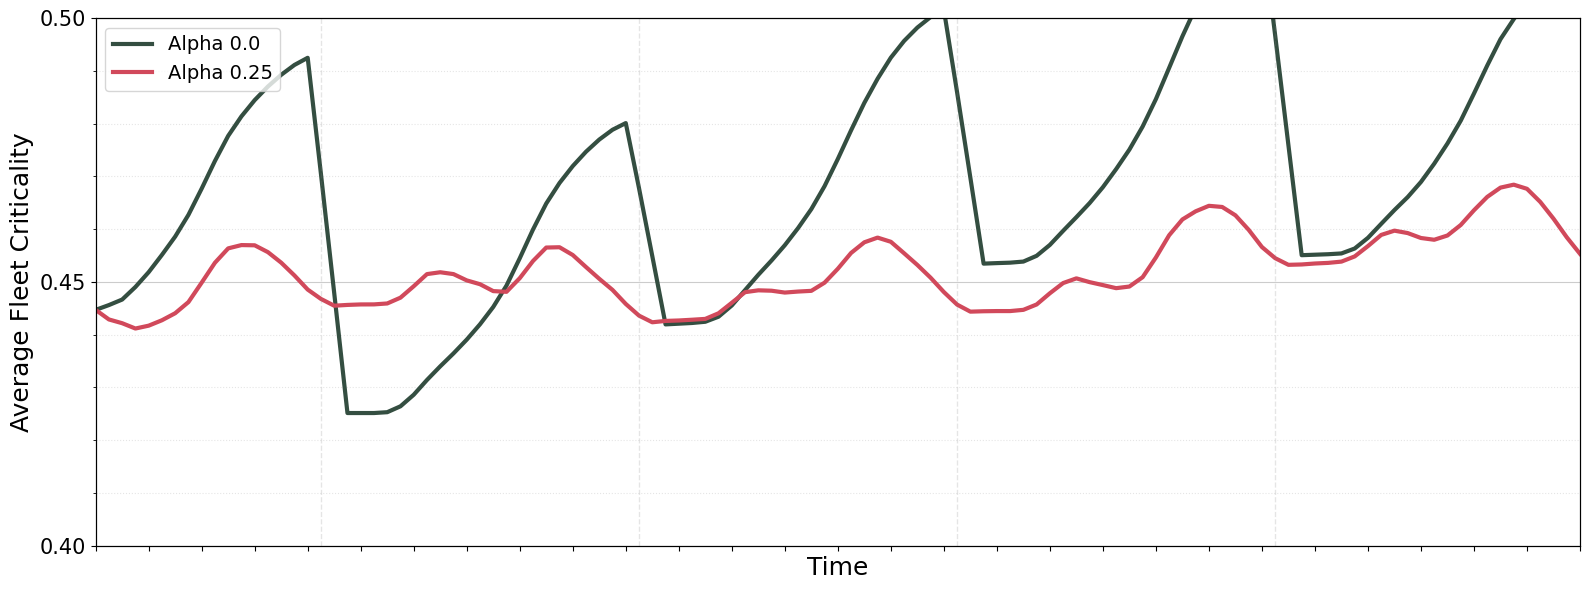

In [162]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ---------------------------
# 0. DEFINE CUSTOM COLORS
# ---------------------------
colors = [
    ("Dark Spruce", "#344E41"),
    ("Warm Red", "#D1495B"),
    ("Ochre Gold", "#EDAE49"),
    ("Blue Accent", "#526ECA"),  
    ("Mist Grey", "#E6E6E6"),
]

# ---------------------------
# 1. HELPER FUNCTIONS
# ---------------------------

# --- MISSING FUNCTION ADDED HERE ---
def apply_time_cap(df):
    """Filters data to only include days up to Day 4 if configured."""
    # Ensure global config exists, default to True if missing
    should_cap = globals().get('CAP_AT_DAY_4', True)
    
    if should_cap:
        return df[df['Day'] <= 4]
    return df

def process_crit_data(df, window=3):
    """
    Cleans the dataframe, trims start time, and calculates Moving Average.
    """
    # 1. Apply the Cap
    c = apply_time_cap(df).copy()
    
    # 2. Safety Check for Columns
    if "Avg Bike Criticality" not in c.columns:
        print(f"⚠️ Warning: 'Avg Bike Criticality' not found in columns: {c.columns.tolist()}")
        return pd.DataFrame() # Return empty if missing
        
    c = c[["Day", "Hour", "Avg Bike Criticality"]]
    
    # 3. Fix incorrect hour value "24" -> Hour 0
    mask_24 = c["Hour"] == 24
    c.loc[mask_24, "Hour"] = 0
    
    # 4. Sort cleanly
    c = c.sort_values(["Day", "Hour"]).reset_index(drop=True)

    # 5. FILTER START TIME (Start at 07:00 on the first day)
    if not c.empty:
        min_day = c["Day"].min()
        mask_start = (c["Day"] > min_day) | ((c["Day"] == min_day) & (c["Hour"] >= 7))
        c = c[mask_start].reset_index(drop=True)
    
        # 6. Moving Average
        c["MA"] = c["Avg Bike Criticality"].rolling(window=window, min_periods=1).mean()
        c["hour_label"] = c["Hour"].astype(str).str.zfill(2) + ":00"
    
    return c

# ---------------------------
# 2. DATA PREPARATION
# ---------------------------
window_size = 3
plot_datasets = [] 

print(f"Preparing Criticality Plot with Trend Line...")

for i, (alpha_val, data_dict) in enumerate(alpha_results.items()):
    
    # Use 'hourly' for Criticality
    if "hourly" in data_dict:
        raw_df = data_dict["hourly"]
        processed_df = process_crit_data(raw_df, window=window_size)
        
        if not processed_df.empty:
            # CYCLE THROUGH CUSTOM COLORS
            color_tuple = colors[i % len(colors)] 
            hex_color = color_tuple[1]
            
            label_text = f"Alpha {alpha_val}"
            plot_datasets.append((label_text, processed_df, hex_color))
    else:
        print(f"⚠️ Missing 'hourly' data for Alpha {alpha_val}")

# ---------------------------
# 3. IDENTIFY X-AXIS & BOUNDARIES
# ---------------------------
if not plot_datasets:
    print("❌ No valid data found to plot.")
else:
    ref_df = plot_datasets[0][1]
    x_ref = ref_df.index

    # Find day boundaries
    day_change_idx = ref_df.index[ref_df["Day"].ne(ref_df["Day"].shift())].tolist()
    boundary_positions = [x for x in day_change_idx if x > 0]

    day_centers = []
    for day_val in ref_df["Day"].unique():
        idxs = ref_df.index[ref_df["Day"] == day_val]
        if len(idxs) > 0:
            center = (idxs[0] + idxs[-1]) / 2
            day_centers.append(center)

    # ---------------------------
    # 4. PLOTTING
    # ---------------------------
    fig, ax = plt.subplots(figsize=(16, 6))

    for label, df, color in plot_datasets:
        ax.plot(df.index, df["MA"], linewidth=3, color=color, label=label)

    # Vertical lines (Day boundaries)
    for pos in boundary_positions:
        ax.axvline(x=pos, color="gray", linestyle="--", linewidth=1, alpha=0.2)

    # ---------------------------
    # AXIS SETTINGS
    # ---------------------------

    # 1. X-Axis Limits (No Gap)
    ax.set_xlim(x_ref[0], x_ref[-1])

    # 2. Y-Axis Limits (Criticality is 0.0 to 1.0)
    # Adjust these if your criticality is on a different scale
    ax.set_ylim(0.4, 0.5) 

    # 3. Granular Ticks
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.01))

    # Grid settings
    ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.4, color='gray')
    ax.grid(True, which='minor', axis='y', linestyle=':', alpha=0.2, color='gray')

    # FONT SIZES
    ax.set_ylabel("Average Fleet Criticality", fontsize=18)
    ax.set_xlabel("Time", fontsize=18)

    # 4. X-Axis (Bottom) - Remove Ticks & Text
    step = max(1, len(ref_df) // 25)
    ax.set_xticks(list(x_ref)[::step])

    # Tick label size
    ax.tick_params(axis='y', labelsize=15)
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    # ---------------------------
    # 5. SECONDARY AXIS (Top)
    # ---------------------------
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim()) 
    ax2.set_xticks(day_centers)
    ax2.xaxis.set_ticks_position("top")
    ax2.xaxis.set_label_position("top")
    ax2.tick_params(axis='x', which='both', bottom=False, top=False, labeltop=False)

    # Legend positioning
    ax.legend(loc='upper left', fontsize=14)

    # 6. SAVE
    plt.tight_layout()

    cap_val = CAP_AT_DAY_4 if 'CAP_AT_DAY_4' in globals() else "Uncapped"
    filename = f"average_fleet_criticality_trend_{cap_val}.svg"
    plt.savefig(
        filename, 
        bbox_inches='tight', 
        pad_inches=0.02
    )

    plt.show()

In [163]:
# values used in the plots and analysis
plt.rcParams.update({
    'figure.figsize': (16, 8),
})

value_size = 13
font_size = 15

### Color palette

In [164]:
colors = [
    ("Pale Fern", "#D9E5D6"),
    ("Sage Green", "#84A579"),
    ("Dark Spruce", "#344E41"),
    ("Warm Red", "#D1495B"),
    ("Ochre Gold", "#EDAE49"),
    ("Blue Accent", "#526ECA"),  
    ("Mist Grey", "#E6E6E6"),
]

## 1.1 State overview

### Seed 1

In [165]:
# --- 7. SUMMARY STATISTICS ---

metrics_dict = {
    "Maintenance Time (minutes)": "sum",
    "Maintenance Violations": "sum",
    "Maintenance Starvations": "sum",
    "Bike Starvations": "sum",
    "Starvations": "sum",
    "Bike Pickups": "sum",
    "Bike Deliveries": "sum",
}

print(f"\n{'='*20} SUMMARY STATISTICS COMPARISON {'='*20}")
print(f"Aggregation Mode: {selection_mode}")

# Initialize a DataFrame to hold the comparison (Rows=Metrics, Cols=Alphas)
summary_comparison = pd.DataFrame()

# Loop through each processed Alpha in your dictionary
for alpha_val, data_dict in alpha_results.items():
    print(f"\nProcessing Alpha {alpha_val}...") 
    print(f"Available Metrics Columns: {data_dict['hourly'].columns.tolist()}")
    
    # 1. Get the hourly data for this alpha
    df_hourly = data_dict["hourly"]
    vehicle_df = data_dict.get("vehicle", pd.DataFrame())
    
    # 2. Filter metrics to ensure they actually exist in the dataframe
    valid_metrics = {k: v for k, v in metrics_dict.items() if k in df_hourly.columns}
    
    if not valid_metrics:
        print(f"Warning: No matching metrics columns found for Alpha {alpha_val}")
        continue
        
    # 3. Aggregate
    # If mode was 'average', this calculates the "Average Total" (e.g., Average Total Pickups)
    agg_series = df_hourly.agg(valid_metrics)
    
    # 4. Add to the comparison table
    summary_comparison[f"Alpha {alpha_val}"] = agg_series

# Display the comparison table
if not summary_comparison.empty:
    # Rounding for cleanliness
    print(summary_comparison.round(2))
else:
    print("No data available to summarize.")


# --- 8. PRINT FILE PATHS USED ---
print("\n" + "="*50)
print("FILES USED:")

# --- 8. PRINT FILE PATHS USED ---
print("\n" + "="*50)
print("FILES USED:")

for alpha_val in alpha_results.keys():
    
    # helper variable for PRINTING ONLY
    alpha_print_str = f"{alpha_val:.3f}" 
    
    # FIX: Pass the raw float 'alpha_val' here, not the string
    available_seeds = get_available_seeds(alpha_val)
    
    # Filter seeds based on your selection mode
    if isinstance(selection_mode, int):
        seeds_to_report = [selection_mode]
    elif selection_mode == "average":
        seeds_to_report = available_seeds
    else:
        seeds_to_report = []

    print(f"\n--- Alpha {alpha_print_str} ({len(seeds_to_report)} seeds) ---")

    for seed in seeds_to_report:
        try:
            # FIX: Pass raw float 'alpha_val' here too
            # Note: Ensure the 'kind' matches your file names (e.g. "vehicle" or "bike_movements")
            # Based on your previous errors, the kind might be "vehicle" or "vehicle_visits"
            
            v_path = get_result_file('vehicle', seed, alpha_val) # or 'bike_movements'
            h_path = get_result_file('hourly', seed, alpha_val)
            s_path = get_result_file('station_hourly', seed, alpha_val)
            t_path = get_result_file('trip_requests', seed, alpha_val)
            
            # Print cleanly
            if v_path: print(f"   Seed {seed}:")
            if v_path: print(f"      Vehicle: {v_path.name}")
            if h_path: print(f"      Hourly:  {h_path.name}")
            
        except Exception as e:
            print(f"   Seed {seed}: [ERROR] {e}")

print("="*50)


==================== SUMMARY STATISTICS COMPARISON ====================
Aggregation Mode: average

Processing Alpha 0.0...
Available Metrics Columns: ['Day', 'Hour', 'Seed', 'Time (minutes)', 'Starvations', 'Bike Starvations', 'Long Congestions', 'Short Congestions', 'Maintenance Violations', 'Maintenance Starvations', 'Bike Pickups', 'Bike Deliveries', 'Maintenance Time (minutes)', 'Avg Bike Criticality', 'Bikes Critical (>0.83)', 'Bikes High (0.60-0.83)', 'Bikes Medium (0.30-0.60)', 'Bikes Low (<=0.30)']

Processing Alpha 0.25...
Available Metrics Columns: ['Day', 'Hour', 'Seed', 'Time (minutes)', 'Starvations', 'Bike Starvations', 'Long Congestions', 'Short Congestions', 'Maintenance Violations', 'Maintenance Starvations', 'Bike Pickups', 'Bike Deliveries', 'Maintenance Time (minutes)', 'Avg Bike Criticality', 'Bikes Critical (>0.83)', 'Bikes High (0.60-0.83)', 'Bikes Medium (0.30-0.60)', 'Bikes Low (<=0.30)']
                            Alpha 0.0  Alpha 0.25
Maintenance Time (minu

# 2 Demand patterns and state insight

In [166]:
# print the instance path used
print(f"Instance used: {instance_path}")

print(vehicle_df.head())

# print number of stations, vehicles used, number of bikes
print(f"Number of vehicles in instance: {vehicle_df['Vehicle ID'].nunique()}")
print(f"Number of stations in instance: {len(stations_df)}")      


Instance used: /Users/minasjovik/Projects/FOMOsim/instances/TD_W34_old.json.gz
   Seed Vehicle ID  Visit Number Station ID  Time (minutes)  Day  Hour  \
0     1         V0             1         S0          420.00    0     7   
1     1         V0             2        S21          439.35    0     7   
2     1         V0             3         S0          453.70    0     7   
3     1         V0             4        S11          466.70    0     7   
4     1         V0             5        S42          476.19    0     7   

   Minute  Time Since Previous Visit (minutes)  
0       0                                 0.00  
1      19                                19.35  
2      33                                14.35  
3      46                                13.00  
4      56                                 9.48  
Number of vehicles in instance: 1
Number of stations in instance: 67


## 2.1 Average demand per hour for the simulation horizon

Generating demand plots for 2 Alpha scenarios...
Selection Mode: average
   -> Plotting Alpha 0.0 (average)...


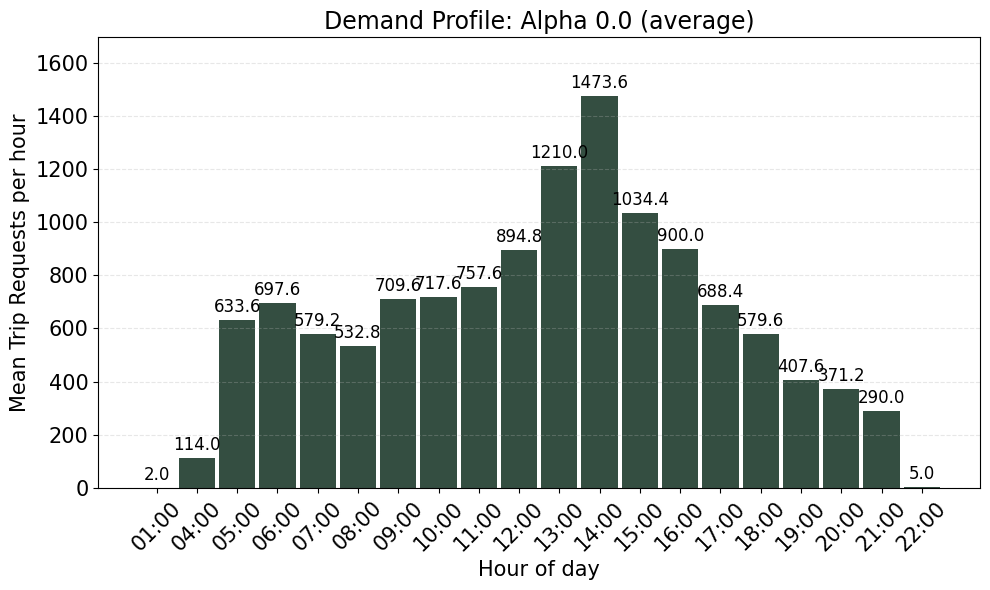

   -> Plotting Alpha 0.25 (average)...


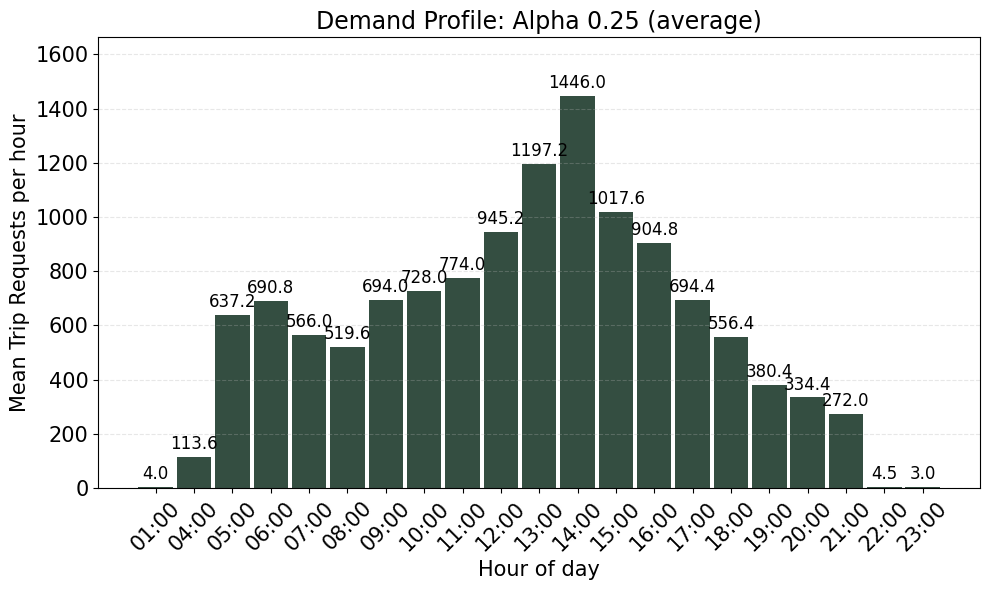

In [167]:
# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_hourly_demand(df_requests, title_label, color_hex):
    """
    Calculates and plots the mean hourly demand for a given trip DataFrame.
    """
    # 1. Count requests for each (Day, Hour) pair
    demand_by_day_hour = (
        df_requests.groupby(["Day", "Hour"])
        .size()
        .reset_index(name="Requests")
    )

    # 2. Compute mean requests per hour across days
    mean_hourly_demand = (
        demand_by_day_hour.groupby("Hour")["Requests"]
        .mean()
        .reset_index()
    )

    hours = mean_hourly_demand["Hour"].tolist()
    demand_vals = mean_hourly_demand["Requests"].tolist()

    # Format x-axis labels as HH:00
    hour_labels = [f"{int(h):02d}:00" for h in hours]

    # --- PLOTTING ---
    plt.figure(figsize=(10, 6)) # Explicit size for consistency
    plt.ylim(0, max(demand_vals)*1.15 if demand_vals else 1)  # Add some headroom
    
    # Use the passed color
    plt.bar(hour_labels, demand_vals, color=color_hex, alpha=1.0, width=0.9)

    plt.xlabel("Hour of day", fontsize=font_size)
    plt.ylabel("Mean Trip Requests per hour", fontsize=font_size)
    plt.title(f"Demand Profile: {title_label}", fontsize=font_size+2)

    # Threshold for determining if bar is "too low"
    threshold = 0.10 * max(demand_vals) if demand_vals else 0

    # Label values on bars
    for h, v in zip(hour_labels, demand_vals):
        # Place label ABOVE the bar
        plt.text(h, v + threshold * 0.1,
                 f"{v:.1f}",
                 ha='center', va='bottom',
                 color='black', fontsize=value_size-1)

    plt.yticks(fontsize=font_size)
    plt.xticks(rotation=45, fontsize=font_size)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Optimize layout FIRST
    plt.tight_layout()
    
    # Save with unique name based on label
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")
    plt.savefig(
        f"mean_trip_requests_{safe_label}.svg", 
        bbox_inches='tight',  # Crops extra white space
        pad_inches=0.02       # Leaves a tiny safety margin
    )

    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC (UPDATED FOR ALPHAS)
# ---------------------------

# Define styling variables if not already in context
if 'font_size' not in locals(): font_size = 14
if 'value_size' not in locals(): value_size = 9
bar_color = colors[2][1]  # Default Orange/Red

print(f"Generating demand plots for {len(alpha_results)} Alpha scenarios...")
print(f"Selection Mode: {selection_mode}")

# Loop through the Alpha Results dictionary
for alpha_val, data_dict in alpha_results.items():
    
    # 1. Extract the Trip Requests dataframe for this Alpha
    current_trips_df = data_dict["trip_requests"]
    
    # 2. Create a label (e.g., "Alpha 0.25 (Average)")
    # Note: If selection_mode is an integer, it will say "Alpha 0.25 (Seed 1)"
    plot_label = f"Alpha {alpha_val} ({selection_mode})"
    
    # 3. Generate Plot
    print(f"   -> Plotting {plot_label}...")
    plot_hourly_demand(
        df_requests=current_trips_df, 
        title_label=plot_label, 
        color_hex=bar_color
    )

## 2.2 Demand across all hours

Generating Full Timeline plots for 2 Alpha scenarios...
Selection Mode: average
   -> Plotting Alpha 0.0 (average) (Normalized by 4 seeds)...


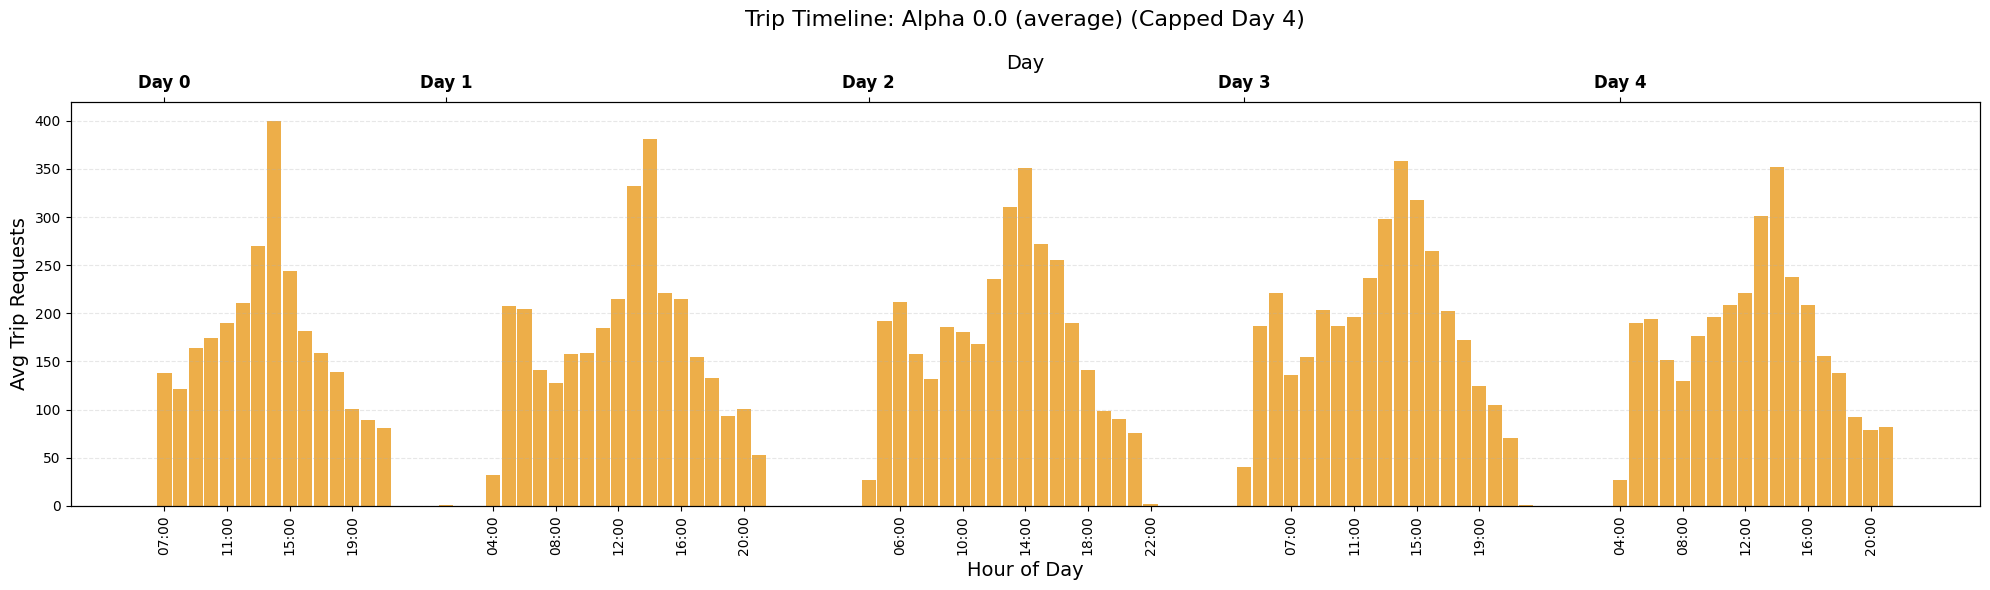

   -> Plotting Alpha 0.25 (average) (Normalized by 4 seeds)...


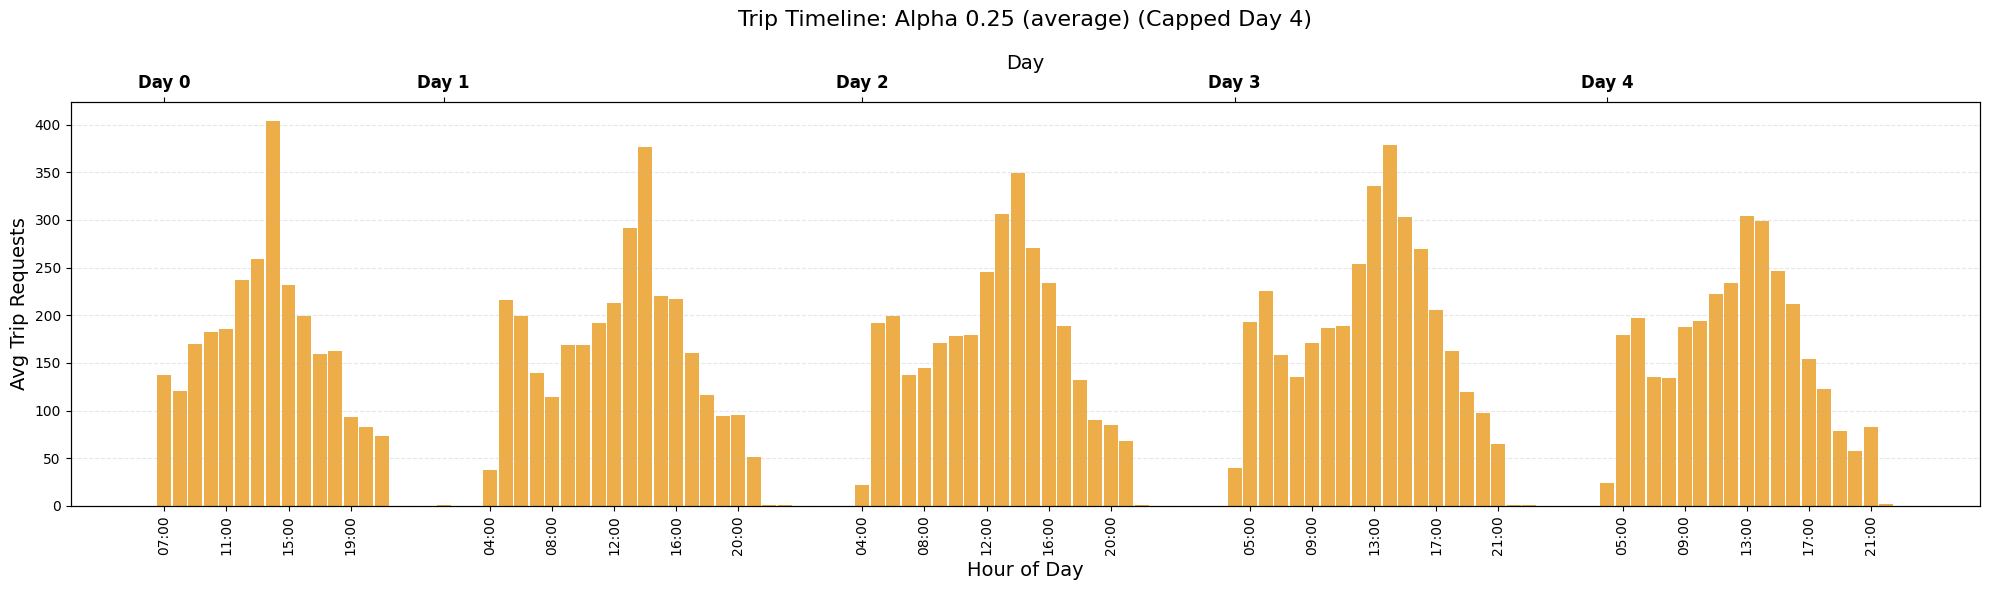

In [168]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 0. SETUP COLORS (Required for Plotting)
# ---------------------------
colors = [
    ("Dark Spruce", "#344E41"),
    ("Warm Red", "#D1495B"),    # colors[1]
    ("Ochre Gold", "#EDAE49"),  # colors[2] -> Used for bars
    ("Blue Accent", "#526ECA"),  
    ("Mist Grey", "#E6E6E6"),
]

# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_full_timeline(df_requests, title_label, scale_factor=1):
    """
    Plots the timeline of requests across all days.
    Applies the global CAP_AT_DAY_4 filter before plotting.
    """
    # 1. APPLY CAP
    # Uses the helper function defined in your loading script
    if 'apply_time_cap' in globals():
        df_filtered = apply_time_cap(df_requests).copy()
    else:
        print("Warning: 'apply_time_cap' function missing. Using full data.")
        df_filtered = df_requests.copy()
    
    if df_filtered.empty:
        print(f"   ⚠️ Warning: No data for {title_label} after filtering.")
        return

    # 2. Count trip requests for each (Day, Hour) pair
    demand_by_day_hour = (
        df_filtered.groupby(["Day", "Hour"])
        .size()
        .reset_index(name="Requests")
    )

    # Normalize if this is an aggregate of multiple seeds
    if scale_factor > 1:
        demand_by_day_hour["Requests"] = demand_by_day_hour["Requests"] / scale_factor

    # Ensure sorting
    demand_by_day_hour = demand_by_day_hour.sort_values(["Day", "Hour"])

    # 3. Prepare flattened index for plotting
    # Create a unique index for each Day-Hour combination
    demand_by_day_hour["DayHourIndex"] = (
        demand_by_day_hour["Day"] * 24 + demand_by_day_hour["Hour"]
    )

    x = demand_by_day_hour["DayHourIndex"]
    y = demand_by_day_hour["Requests"]

    # Bottom x-axis label = hour (formatted)
    hour_labels = [f"{int(h):02d}:00" for h in demand_by_day_hour["Hour"]]

    # Top x-axis labels = day
    day_ticks = (
        demand_by_day_hour.groupby("Day")["DayHourIndex"]
        .min()
        .values
    )
    day_labels = [f"Day {int(d)}" for d in demand_by_day_hour["Day"].unique()]

    # 4. Plot
    fig, ax1 = plt.subplots(figsize=(20, 6))

    bar_color = colors[2][1]   # Ochre Gold

    ax1.bar(x, y, width=0.9, color=bar_color)

    ylabel_text = "Avg Trip Requests" if scale_factor > 1 else "Trip Requests"
    ax1.set_ylabel(ylabel_text, fontsize=14)
    ax1.set_xlabel("Hour of Day", fontsize=14)

    # Bottom axis -> hours
    # Show every 4th hour if capped, or every 6th if full week to avoid crowding
    step = 4 if CAP_AT_DAY_4 else 6
    
    # Ensure step isn't larger than available data
    step = min(step, len(x)) if len(x) > 0 else 1
    
    ax1.set_xticks(list(x)[::step]) 
    ax1.set_xticklabels([hour_labels[i] for i in range(0, len(hour_labels), step)], 
                        rotation=90, fontsize=10)

    # 5. Add top axis -> days
    ax2 = ax1.twiny()
    ax2.set_xlim(ax1.get_xlim())
    ax2.set_xticks(day_ticks)
    ax2.set_xticklabels(day_labels, fontsize=12, fontweight="bold")
    ax2.set_xlabel("Day", fontsize=14)

    # 6. Styling & Saving
    ax1.grid(axis='y', linestyle='--', alpha=0.3)
    
    cap_text = "(Capped Day 4)" if CAP_AT_DAY_4 else "(Full Week)"
    # Title includes Alpha implicitly via title_label passed from loop
    plt.title(f"Trip Timeline: {title_label} {cap_text}", fontsize=16, pad=20)
    
    safe_name = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")
    
    plt.tight_layout()
    plt.savefig(
        f"full_timeline_requests_{safe_name}_capped_{CAP_AT_DAY_4}.svg",
        bbox_inches='tight',
        pad_inches=0.02
    )
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC (CORRECTED)
# ---------------------------

print(f"Generating Full Timeline plots for {len(alpha_results)} Alpha scenarios...")
print(f"Selection Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Prepare Label
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    # 2. Determine Scale Factor (for Averaging)
    # FIX: Pass the raw float 'alpha_val' to the robust helper function
    seeds_used = get_available_seeds(alpha_val) 
    
    if selection_mode == "average":
        scale = len(seeds_used)
        print(f"   -> Plotting {label_text} (Normalized by {scale} seeds)...")
    else:
        scale = 1
        print(f"   -> Plotting {label_text} (Single Seed)...")

    # 3. Check if Data Exists
    # FIX: Use the correct key 'trip_requests_df' from the new loader
    if "trip_requests" in data_dict:
        plot_full_timeline(
            df_requests=data_dict["trip_requests"],
            title_label=label_text,
            scale_factor=scale
        )
    else:
        print(f"   ⚠️ Missing 'trip_requests_df' for Alpha {alpha_val}")

# 3 Trip requests and fleet aspects

## 3.1 Average fleet criticality

### 3.1.1 Line plot during the day

Preparing Criticality Plot with Trend Line...


/var/folders/yq/llblptc118lf6wvmlzl8550r0000gn/T/ipykernel_60277/399889574.py:99: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_trend = trend_source_df["MA"].fillna(method='bfill') # Fill NaNs for calculation


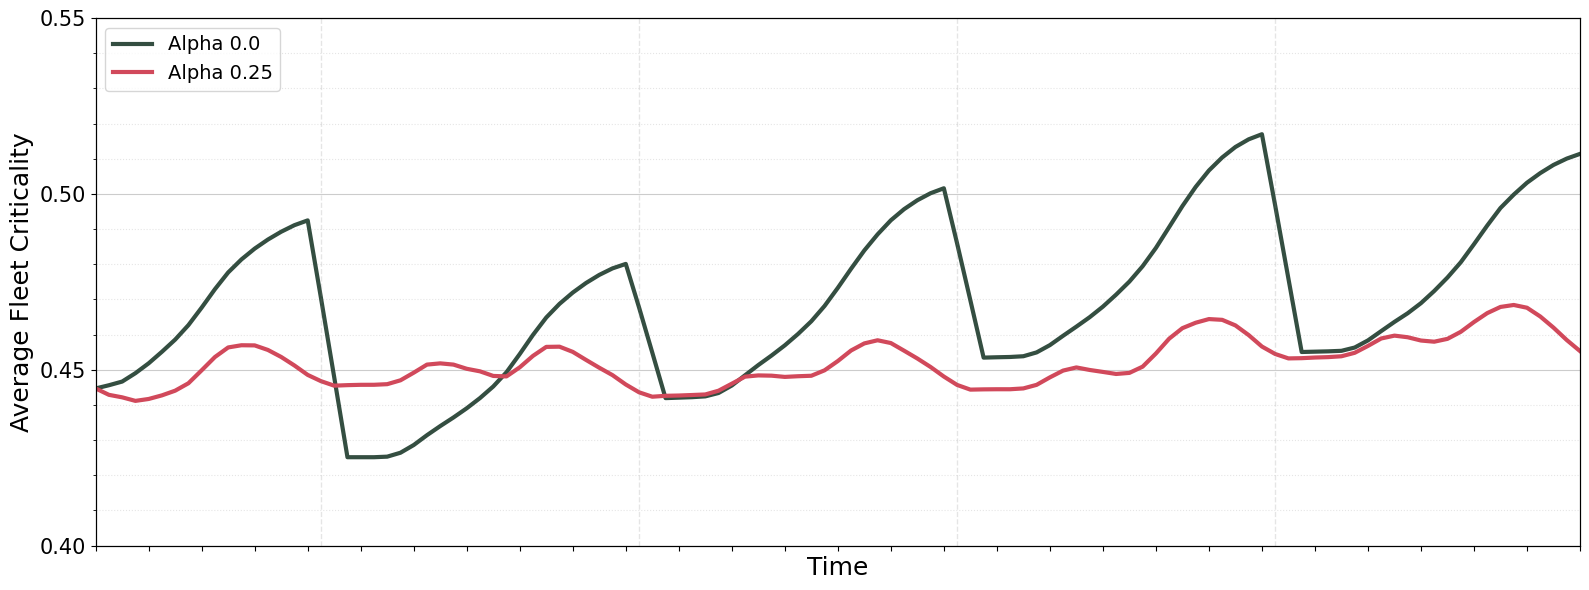

In [169]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ---------------------------
# 0. DEFINE CUSTOM COLORS
# ---------------------------
colors = [
    ("Dark Spruce", "#344E41"),
    ("Warm Red", "#D1495B"),
    ("Ochre Gold", "#EDAE49"),
    ("Blue Accent", "#526ECA"),  
    ("Mist Grey", "#E6E6E6"),
]

# ---------------------------
# 1. HELPER FUNCTION
# ---------------------------
def process_crit_data(df, window=3):
    """
    Cleans the dataframe, trims start time, and calculates Moving Average.
    """
    c = apply_time_cap(df).copy()
    c = c[["Day", "Hour", "Avg Bike Criticality"]]
    
    # Fix incorrect hour value "24" -> Hour 0
    mask_24 = c["Hour"] == 24
    c.loc[mask_24, "Hour"] = 0
    
    # Sort cleanly
    c = c.sort_values(["Day", "Hour"]).reset_index(drop=True)

    # --- FILTER START TIME (Start at 07:00 on the first day) ---
    min_day = c["Day"].min()
    mask_start = (c["Day"] > min_day) | ((c["Day"] == min_day) & (c["Hour"] >= 7))
    c = c[mask_start].reset_index(drop=True)
    
    # Moving Average
    c["MA"] = c["Avg Bike Criticality"].rolling(window=window, min_periods=1).mean()
    c["hour_label"] = c["Hour"].astype(str).str.zfill(2) + ":00"
    
    return c

# ---------------------------
# 2. DATA PREPARATION
# ---------------------------
window_size = 3
plot_datasets = [] 

print(f"Preparing Criticality Plot with Trend Line...")

for i, (alpha_val, data_dict) in enumerate(alpha_results.items()):
    raw_df = data_dict["hourly"]
    processed_df = process_crit_data(raw_df, window=window_size)
    
    # CYCLE THROUGH CUSTOM COLORS
    color_tuple = colors[i % len(colors)] 
    hex_color = color_tuple[1]
    
    label_text = f"Alpha {alpha_val}"
    plot_datasets.append((label_text, processed_df, hex_color))

# ---------------------------
# 3. IDENTIFY X-AXIS & BOUNDARIES
# ---------------------------
if not plot_datasets:
    raise ValueError("No data found to plot.")

ref_df = plot_datasets[0][1]
x_ref = ref_df.index

# Find day boundaries
day_change_idx = ref_df.index[ref_df["Day"].ne(ref_df["Day"].shift())].tolist()
boundary_positions = [x for x in day_change_idx if x > 0]

day_centers = []
for day_val in ref_df["Day"].unique():
    idxs = ref_df.index[ref_df["Day"] == day_val]
    if len(idxs) > 0:
        center = (idxs[0] + idxs[-1]) / 2
        day_centers.append(center)

# ---------------------------
# 4. PLOTTING
# ---------------------------
fig, ax = plt.subplots(figsize=(16, 6))

for label, df, color in plot_datasets:
    ax.plot(df.index, df["MA"], linewidth=3, color=color, label=label)

# --- 4b. ADD TREND LINE (GROWTH LINE) ---
# We calculate the trend based on the FIRST dataset (usually Alpha 0 or the baseline)
# You can change index [0] to another index if you want the trend of a different Alpha
trend_source_df = plot_datasets[0][1] 

# Create x values (0, 1, 2...) matching the index
x_trend = np.arange(len(trend_source_df))
y_trend = trend_source_df["MA"].fillna(method='bfill') # Fill NaNs for calculation

# Calculate Linear Regression (Polyfit degree 1)
#slope, intercept = np.polyfit(x_trend, y_trend, 1)

# Generate Y values for the line
#trend_line_y = slope * x_trend + intercept

# Plot the trend line
#ax.plot(x_trend, trend_line_y, color="black", linestyle="--", linewidth=2, 
        #label=f"Trend (Slope: {slope:.4f})", alpha=0.6)
# ----------------------------------------


# Vertical lines (Day boundaries)
for pos in boundary_positions:
    ax.axvline(x=pos, color="gray", linestyle="--", linewidth=1, alpha=0.2)

# ---------------------------
# AXIS SETTINGS
# ---------------------------

# 1. X-Axis Limits (No Gap)
ax.set_xlim(x_ref[0], x_ref[-1])

# 2. Y-Axis Limits
ax.set_ylim(0.40, 0.55)

# 3. Granular Ticks
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.01))

# Grid settings
ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.4, color='gray')
ax.grid(True, which='minor', axis='y', linestyle=':', alpha=0.2, color='gray')

# FONT SIZES
ax.set_ylabel("Average Fleet Criticality", fontsize=18)
ax.set_xlabel("Time", fontsize=18)

# 4. X-Axis (Bottom) - Remove Ticks & Text
step = max(1, len(ref_df) // 25)
ax.set_xticks(list(x_ref)[::step])

# Tick label size
ax.tick_params(axis='y', labelsize=15)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# ---------------------------
# 5. SECONDARY AXIS (Top) - Remove Ticks & Text
# ---------------------------
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim()) 
ax2.set_xticks(day_centers)
ax2.xaxis.set_ticks_position("top")
ax2.xaxis.set_label_position("top")
ax2.tick_params(axis='x', which='both', bottom=False, top=False, labeltop=False)

# Legend positioning
ax.legend(loc='upper left', fontsize=14)

# 6. SAVE
plt.tight_layout()

filename = f"average_fleet_criticality_{alpha_val}_trendline_{CAP_AT_DAY_4}.svg"
plt.savefig(
    filename, 
    bbox_inches='tight', 
    pad_inches=0.02
)

plt.show()

Preparing Criticality Plot with Trend Line...


/var/folders/yq/llblptc118lf6wvmlzl8550r0000gn/T/ipykernel_60277/27699511.py:101: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_trend = trend_source_df["MA"].fillna(method='bfill').fillna(method='ffill')


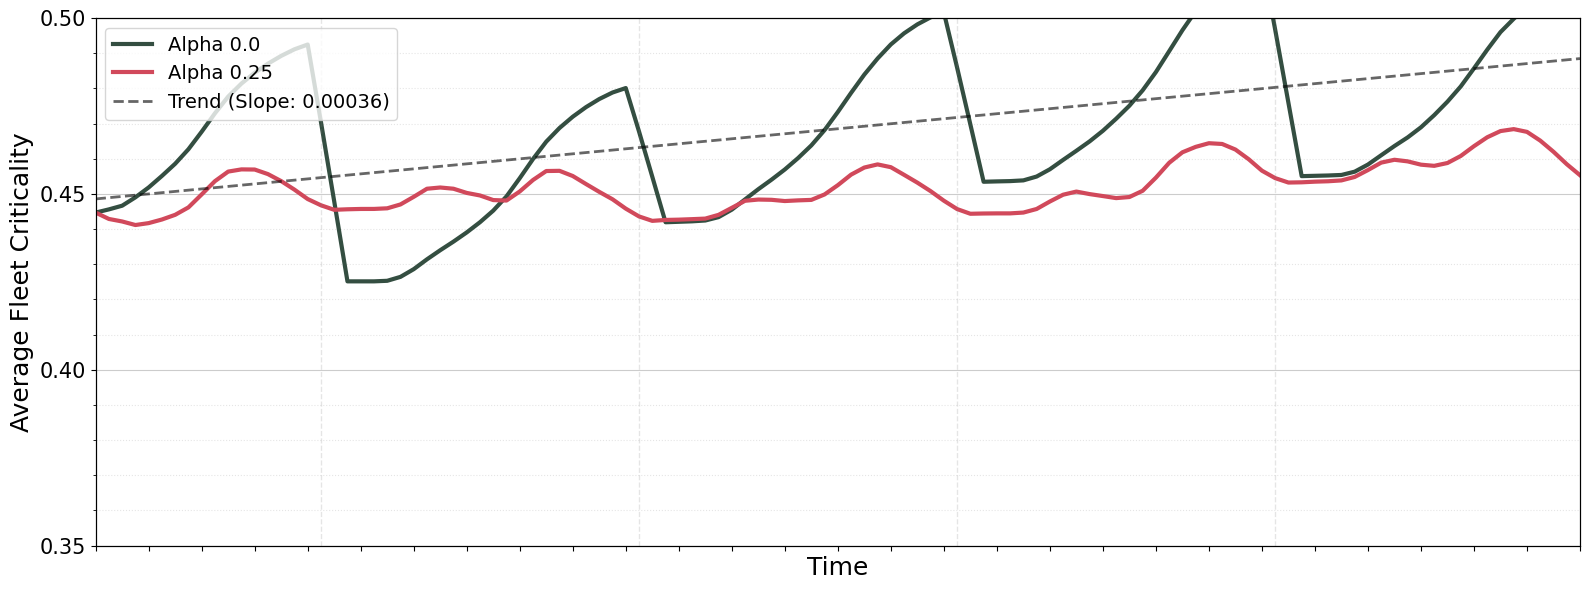

In [170]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ---------------------------
# 0. DEFINE CUSTOM COLORS
# ---------------------------
colors = [
    ("Dark Spruce", "#344E41"),
    ("Warm Red", "#D1495B"),
    ("Ochre Gold", "#EDAE49"),
    ("Blue Accent", "#526ECA"),  
    ("Mist Grey", "#E6E6E6"),
]

# ---------------------------
# 1. HELPER FUNCTION
# ---------------------------
def process_crit_data(df, window=3):
    """
    Cleans the dataframe, trims start time, and calculates Moving Average.
    """
    c = apply_time_cap(df).copy()
    c = c[["Day", "Hour", "Avg Bike Criticality"]]
    
    # Fix incorrect hour value "24" -> Hour 0
    mask_24 = c["Hour"] == 24
    c.loc[mask_24, "Hour"] = 0
    
    # Sort cleanly
    c = c.sort_values(["Day", "Hour"]).reset_index(drop=True)

    # --- FILTER START TIME (Start at 07:00 on the first day) ---
    min_day = c["Day"].min()
    mask_start = (c["Day"] > min_day) | ((c["Day"] == min_day) & (c["Hour"] >= 7))
    c = c[mask_start].reset_index(drop=True)
    
    # Moving Average
    c["MA"] = c["Avg Bike Criticality"].rolling(window=window, min_periods=1).mean()
    c["hour_label"] = c["Hour"].astype(str).str.zfill(2) + ":00"
    
    return c

# ---------------------------
# 2. DATA PREPARATION
# ---------------------------
window_size = 3
plot_datasets = [] 

print(f"Preparing Criticality Plot with Trend Line...")

for i, (alpha_val, data_dict) in enumerate(alpha_results.items()):
    raw_df = data_dict["hourly"]
    processed_df = process_crit_data(raw_df, window=window_size)
    
    # CYCLE THROUGH CUSTOM COLORS
    color_tuple = colors[i % len(colors)] 
    hex_color = color_tuple[1]
    
    label_text = f"Alpha {alpha_val}"
    plot_datasets.append((label_text, processed_df, hex_color))

# ---------------------------
# 3. IDENTIFY X-AXIS & BOUNDARIES
# ---------------------------
if not plot_datasets:
    raise ValueError("No data found to plot.")

ref_df = plot_datasets[0][1]
x_ref = ref_df.index

# Find day boundaries
day_change_idx = ref_df.index[ref_df["Day"].ne(ref_df["Day"].shift())].tolist()
boundary_positions = [x for x in day_change_idx if x > 0]

day_centers = []
for day_val in ref_df["Day"].unique():
    idxs = ref_df.index[ref_df["Day"] == day_val]
    if len(idxs) > 0:
        center = (idxs[0] + idxs[-1]) / 2
        day_centers.append(center)

# ---------------------------
# 4. PLOTTING
# ---------------------------
fig, ax = plt.subplots(figsize=(16, 6))

for label, df, color in plot_datasets:
    ax.plot(df.index, df["MA"], linewidth=3, color=color, label=label)

# --- 4b. ADD TREND LINE (GROWTH LINE) ---
# We calculate the trend based on the FIRST dataset (usually Alpha 0 or the baseline)
# You can change index [0] to another index if you want the trend of a different Alpha
trend_source_df = plot_datasets[0][1] 

# Create x values (0, 1, 2...) matching the index
x_trend = np.arange(len(trend_source_df))

# Clean data: fill NaNs at start (bfill) AND end (ffill) to ensure polyfit doesn't crash
y_trend = trend_source_df["MA"].fillna(method='bfill').fillna(method='ffill')

# Calculate Linear Regression (Polyfit degree 1)
slope, intercept = np.polyfit(x_trend, y_trend, 1)

# Generate Y values for the line
trend_line_y = slope * x_trend + intercept

# Plot the trend line (Uncommented and active)
ax.plot(x_trend, trend_line_y, color="black", linestyle="--", linewidth=2, 
        label=f"Trend (Slope: {slope:.5f})", alpha=0.6)
# ----------------------------------------


# Vertical lines (Day boundaries)
for pos in boundary_positions:
    ax.axvline(x=pos, color="gray", linestyle="--", linewidth=1, alpha=0.2)

# ---------------------------
# AXIS SETTINGS
# ---------------------------

# 1. X-Axis Limits (No Gap)
ax.set_xlim(x_ref[0], x_ref[-1])

# 2. Y-Axis Limits
ax.set_ylim(0.35, 0.5)

# 3. Granular Ticks
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.01))

# Grid settings
ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.4, color='gray')
ax.grid(True, which='minor', axis='y', linestyle=':', alpha=0.2, color='gray')

# FONT SIZES
ax.set_ylabel("Average Fleet Criticality", fontsize=18)
ax.set_xlabel("Time", fontsize=18)

# 4. X-Axis (Bottom) - Remove Ticks & Text
step = max(1, len(ref_df) // 25)
ax.set_xticks(list(x_ref)[::step])

# Tick label size
ax.tick_params(axis='y', labelsize=15)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# ---------------------------
# 5. SECONDARY AXIS (Top) - Remove Ticks & Text
# ---------------------------
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim()) 
ax2.set_xticks(day_centers)
ax2.xaxis.set_ticks_position("top")
ax2.xaxis.set_label_position("top")
ax2.tick_params(axis='x', which='both', bottom=False, top=False, labeltop=False)

# Legend positioning
ax.legend(loc='upper left', fontsize=14)

# 6. SAVE
plt.tight_layout()

filename = f"average_fleet_criticality_{alpha_val}_trendline_{CAP_AT_DAY_4}.svg"
plt.savefig(
    filename, 
    bbox_inches='tight', 
    pad_inches=0.02
)

plt.show()

### 3.1.2 Map showing average criticality of all stations

In [171]:
import folium
import numpy as np
import pandas as pd
import os

# ---------------------------
# 1. DIAGNOSTIC: CHECK WHAT DATA IS LOADED
# ---------------------------
print(f"{'='*20} DATA DIAGNOSTIC {'='*20}")
if not alpha_results:
    print("❌ alpha_results is EMPTY! You must run the 'Data Loading' script first.")
else:
    for alpha, data in alpha_results.items():
        keys_found = list(data.keys())
        print(f"Alpha {alpha}: Found keys -> {keys_found}")
        
        # Check specifically for station data
        has_station = any("station" in k for k in keys_found)
        if not has_station:
            print(f"   ⚠️ WARNING: No 'station' data found for Alpha {alpha}. Map generation will fail.")

print("="*60 + "\n")

# ---------------------------
# 2. HELPER: COLOR FUNCTION
# ---------------------------
def crit_color(c):
    if c >= 0.6: return "red"
    elif c >= 0.5: return "orange"
    elif c >= 0.4: return "yellow"
    else: return "green"

# ---------------------------
# 3. MAP GENERATION LOGIC
# ---------------------------
print(f"Generating Station Maps for {len(alpha_results)} Alpha scenarios...")

# 0. PREPARE STATIC STATIONS DATAFRAME
# We need to ensure 'id' is numeric for merging with the simulation results
map_stations_df = stations_df.copy()

# Robust 'id' creation for the static map data
if not map_stations_df.empty:
    # If 'id' missing but 'Station ID' exists, copy it
    if "id" not in map_stations_df.columns and "Station ID" in map_stations_df.columns:
        map_stations_df["id"] = map_stations_df["Station ID"]
    
    # Ensure 'id' is integer
    if "id" in map_stations_df.columns:
        try:
            # Handle cases like "S1", "Station 1"
            if map_stations_df["id"].dtype == object:
                 map_stations_df["id"] = map_stations_df["id"].astype(str).str.extract(r'(\d+)').fillna(0).astype(int)
            else:
                 map_stations_df["id"] = map_stations_df["id"].astype(int)
        except Exception as e:
            print(f"⚠️ Warning: Issue converting static station IDs: {e}")

for alpha_val, data_dict in alpha_results.items():
    
    # -------------------------------------------------------
    # A. KEY HUNTER (Finds the dataframe regardless of name)
    # -------------------------------------------------------
    station_hourly_activity_df = None
    
    # List of possible keys the loader might have used
    possible_keys = ["station_hourly_df", "station_hourly", "station_df", "station"]
    
    found_key = None
    for k in possible_keys:
        if k in data_dict:
            station_hourly_activity_df = data_dict[k].copy()
            found_key = k
            break
            
    if station_hourly_activity_df is None:
        print(f"   -> Skipping Alpha {alpha_val}: Station data not found (Checked keys: {possible_keys})")
        continue

    print(f"   -> Processing Map for Alpha {alpha_val} (Using data from '{found_key}')...")

    # -------------------------------------------------------
    # B. STANDARDIZE ID IN SIMULATION DATA
    # -------------------------------------------------------
    if "Station ID" in station_hourly_activity_df.columns:
        # Extract digits from "S21" -> 21
        if station_hourly_activity_df["Station ID"].dtype == object:
            station_hourly_activity_df["id"] = (
                station_hourly_activity_df["Station ID"]
                .astype(str)
                .str.extract(r"(\d+)")
                .fillna(0)
                .astype(int)
            )
        else:
            station_hourly_activity_df["id"] = station_hourly_activity_df["Station ID"].astype(int)
    else:
        print("      ⚠️ 'Station ID' column missing in simulation data.")
        continue

    # -------------------------------------------------------
    # C. COMPUTE METRICS
    # -------------------------------------------------------
    # 1. Broken Share
    if "Unusable Bikes" in station_hourly_activity_df.columns and "Capacity" in station_hourly_activity_df.columns:
        station_hourly_activity_df["broken_share"] = (
            station_hourly_activity_df["Unusable Bikes"] /
            station_hourly_activity_df["Capacity"].replace(0, np.nan)
        )
    else:
        station_hourly_activity_df["broken_share"] = 0.0

    # 2. Criticality
    # Check for common column names
    crit_col = "Avg Maintenance Criticality"
    if crit_col not in station_hourly_activity_df.columns:
        # Try finding a similar column
        alternatives = [c for c in station_hourly_activity_df.columns if "Criticality" in c and "Maint" in c]
        if alternatives: crit_col = alternatives[0]

    agg_spec = {"broken_share": "mean"}
    if crit_col in station_hourly_activity_df.columns:
        agg_spec[crit_col] = "mean"

    # Aggregate by Station ID
    crit_per_station = (
        station_hourly_activity_df
        .groupby("id", as_index=False)
        .agg(agg_spec)
    )
    
    # Rename columns for merging
    if crit_col in crit_per_station.columns:
        crit_per_station.rename(columns={crit_col: "avg_maint_crit"}, inplace=True)
    else:
        crit_per_station["avg_maint_crit"] = 0.0 # Default if missing
        
    crit_per_station.rename(columns={"broken_share": "avg_broken_share"}, inplace=True)

    # -------------------------------------------------------
    # D. MERGE & MAP
    # -------------------------------------------------------
    stations_crit = map_stations_df.merge(crit_per_station, on="id", how="left")
    
    stations_crit["avg_maint_crit"] = stations_crit["avg_maint_crit"].fillna(0.0)
    stations_crit["avg_broken_share"] = stations_crit["avg_broken_share"].fillna(0.0)

    # Check for lat/lon
    if "lat" in stations_crit.columns and "lon" in stations_crit.columns:
        # Filter out bad coordinates
        valid_stations = stations_crit.dropna(subset=["lat", "lon"])
        
        if valid_stations.empty:
            print("      ⚠️ No valid stations with coordinates found.")
            continue
            
        center_lat = valid_stations["lat"].mean()
        center_lon = valid_stations["lon"].mean()
        
        m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

        for _, row in valid_stations.iterrows():
            c = row["avg_maint_crit"]
            broken_pct = row["avg_broken_share"] * 100 

            folium.CircleMarker(
                location=[row["lat"], row["lon"]],
                radius=6,  
                fill=True,
                fill_opacity=0.8,
                color=crit_color(c),
                fill_color=crit_color(c),
                popup=(
                    f"Station S{int(row['id'])}<br>"
                    f"Alpha: {alpha_val}<br>"
                    f"Avg maint. criticality: {c:.3f}<br>"
                    f"Avg broken: {broken_pct:.1f}% of capacity"
                ),
            ).add_to(m)

        # Save Map
        mode_label = f"seed_{selection_mode}" if isinstance(selection_mode, int) else selection_mode
        filename = f"station_criticality_map_{mode_label}_Alpha_{alpha_val}.html"
        
        m.save(filename)
        print(f"      ✅ Saved: {filename}")
    else:
        print("      ⚠️ Missing lat/lon in stations_df. Cannot generate map.")

print("\nDone.")

==================== DATA DIAGNOSTIC ====================
Alpha 0.0: Found keys -> ['hourly', 'vehicle', 'bike_movements_df', 'trip_requests']
   ⚠️ WARNING: No 'station' data found for Alpha 0.0. Map generation will fail.
Alpha 0.25: Found keys -> ['hourly', 'vehicle', 'bike_movements_df', 'trip_requests']
   ⚠️ WARNING: No 'station' data found for Alpha 0.25. Map generation will fail.

Generating Station Maps for 2 Alpha scenarios...
   -> Skipping Alpha 0.0: Station data not found (Checked keys: ['station_hourly_df', 'station_hourly', 'station_df', 'station'])
   -> Skipping Alpha 0.25: Station data not found (Checked keys: ['station_hourly_df', 'station_hourly', 'station_df', 'station'])

Done.


## 3.2 Service rate computation

In [ ]:
# ---------------------------
# 1. METRIC CALCULATION FUNCTION (Unchanged)
# ---------------------------
def calculate_service_metrics(df_trips, df_hourly, scale_factor=1):
    """
    Calculates system-wide service metrics.
    """
    # 1. Total Requests (Normalized)
    raw_requests = len(df_trips)
    total_requests = raw_requests / scale_factor
    
    # 2. Successful Trips (Normalized)
    if "Failure Reason" in df_trips.columns:
        raw_successful = df_trips["Failure Reason"].isna().sum()
    else:
        # Fallback if column missing: assume all rows are successes unless specified
        raw_successful = len(df_trips)

    total_successful = raw_successful / scale_factor
    
    # 3. Total Long Congestions
    # df_hourly is already averaged in the loading phase, so we just sum the averages.
    total_long_congestions = df_hourly["Long Congestions"].sum()
    
    # 4. Effective Success (Penalized by Congestion)
    effective_total_successful = max(total_successful - total_long_congestions, 0)
    
    # 5. Service Rate
    service_rate = (effective_total_successful / total_requests) if total_requests > 0 else 0
    
    return {
        "Total Requests": round(total_requests, 1),
        "Successful Trips": round(total_successful, 1),
        "Long Congestions": round(total_long_congestions, 1),
        "Effective Success": round(effective_total_successful, 1),
        "Service Rate": service_rate 
    }

# ---------------------------
# 2. EXECUTION LOGIC (Updated for ML)
# ---------------------------

print(f"\n{'='*20} SERVICE LEVEL ANALYSIS COMPARISON {'='*20}")
print(f"Aggregation Mode: {selection_mode}")

comparison_list = []

# Loop through the sim_results dictionary
# Key is now a tuple: (alpha_val, ml_val)
for (alpha_val, ml_val), data_dict in sim_results.items():
    
    # 1. Determine Scale Factor
    if selection_mode == "average":
        # Use the updated get_available_seeds function we wrote earlier
        seeds_used = get_available_seeds(alpha_val, ml_val=ml_val)
        scale = len(seeds_used)
        if scale == 0: scale = 1 # Safety to avoid divide by zero
    else:
        scale = 1 # Single seed mode or "all" mode (if treating "all" as individual rows, logic might differ)
        
    # 2. Calculate Metrics
    # Note: trip_requests is stacked (Total of all seeds), hourly is averaged (Mean of all seeds)
    metrics = calculate_service_metrics(
        df_trips=data_dict["trip_requests"],
        df_hourly=data_dict["hourly"],
        scale_factor=scale
    )
    
    # 3. Add Identity info
    metrics["Alpha"] = alpha_val
    # Handle None for Legacy files
    metrics["ML"] = ml_val if ml_val is not None else "Legacy"
    
    comparison_list.append(metrics)

# ---------------------------
# 3. DISPLAY RESULTS
# ---------------------------
if comparison_list:
    # Create DataFrame
    results_df = pd.DataFrame(comparison_list)
    
    # Reorder columns to put Alpha and ML first
    cols = ["Alpha", "ML", "Service Rate", "Total Requests", "Successful Trips", "Long Congestions", "Effective Success"]
    results_df = results_df[cols]
    
    # Sort for cleaner reading
    results_df = results_df.sort_values(by=["Alpha", "ML"])
    
    # Format for Display
    display_df = results_df.copy()
    display_df["Service Rate"] = display_df["Service Rate"].apply(lambda x: f"{x:.2%}")
    
    print("\n")
    print(display_df.to_string(index=False))
    
    # Quick Best Performer Check
    best_idx = results_df["Service Rate"].idxmax()
    best_row = results_df.loc[best_idx]
    
    print(f"\nBest Performing Policy:")
    print(f"  Alpha: {best_row['Alpha']}")
    print(f"  ML:    {best_row['ML']}")
    print(f"  Rate:  {best_row['Service Rate']:.2%}")

else:
    print("No data available for analysis.")

print("=" * 60)


==================== SERVICE LEVEL ANALYSIS COMPARISON ====================
Aggregation Mode: average


TypeError: cannot unpack non-iterable float object

In [ ]:
# ---------------------------
# 1. METRIC CALCULATION FUNCTION
# ---------------------------
def calculate_service_metrics(df_trips, df_hourly, scale_factor=1):
    """
    Calculates system-wide service metrics.
    
    Args:
        df_trips: DataFrame containing trip logs.
        df_hourly: DataFrame containing hourly stats (must contain 'Long Congestions').
        scale_factor: int/float. Used to normalize trip counts if df_trips contains 
                      stacked data from multiple seeds. 
                      (e.g., if Average mode over 5 seeds, scale_factor=5).
    """
    # 1. Total Requests (Normalized)
    raw_requests = len(df_trips)
    total_requests = raw_requests / scale_factor
    
    # 2. Successful Trips (Normalized)
    # A trip is successful if "Failure Reason" is NaN
    raw_successful = df_trips["Failure Reason"].isna().sum()
    total_successful = raw_successful / scale_factor
    
    # 3. Total Long Congestions
    # If df_hourly is already an 'average' dataframe, sum() gives the average weekly total.
    # If df_hourly is a single seed, sum() gives that seed's total.
    total_long_congestions = df_hourly["Long Congestions"].sum()
    
    # 4. Effective Success (Penalized by Congestion)
    # We subtract congestions from successes to account for trips that 'succeeded' 
    # but arrived at a full station (blocked).
    effective_total_successful = max(total_successful - total_long_congestions, 0)
    
    # 5. Service Rate
    service_rate = (effective_total_successful / total_requests) if total_requests > 0 else 0
    
    return {
        "Total Requests": round(total_requests, 1),
        "Successful Trips": round(total_successful, 1),
        "Long Congestions": round(total_long_congestions, 1),
        "Effective Success": round(effective_total_successful, 1),
        "Service Rate": service_rate # Keep as float for formatting later
    }

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

print(f"\n{'='*20} SERVICE LEVEL ANALYSIS COMPARISON {'='*20}")
print(f"Aggregation Mode: {selection_mode}")

comparison_list = []

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Determine Scale Factor
    # We need to know how many seeds were used for THIS specific alpha to normalize correctly
    if selection_mode == "average":
        alpha_str = f"{alpha_val:.3f}"
        seeds_used = get_available_seeds(alpha_str) # Re-scan to get count
        scale = len(seeds_used)
    else:
        scale = 1 # Single seed mode
        
    # 2. Calculate Metrics
    metrics = calculate_service_metrics(
        df_trips=data_dict["trip_requests"],
        df_hourly=data_dict["hourly"],
        scale_factor=scale
    )
    
    # 3. Add Identity info
    metrics["Alpha"] = alpha_val
    comparison_list.append(metrics)

# ---------------------------
# 3. DISPLAY RESULTS
# ---------------------------
if comparison_list:
    # Create DataFrame
    results_df = pd.DataFrame(comparison_list)
    
    # Reorder columns to put Alpha first
    cols = ["Alpha", "Total Requests", "Successful Trips", "Long Congestions", "Effective Success", "Service Rate"]
    results_df = results_df[cols]
    
    # Format Service Rate as percentage string for display
    # (We operate on a copy for display so we don't break the float values if needed later)
    display_df = results_df.copy()
    display_df["Service Rate"] = display_df["Service Rate"].apply(lambda x: f"{x:.2%}")
    
    print("\n")
    print(display_df.to_string(index=False))
    
    # Optional: Quick textual summary of the best Alpha
    best_alpha_idx = results_df["Service Rate"].idxmax()
    best_alpha = results_df.loc[best_alpha_idx, "Alpha"]
    best_rate = results_df.loc[best_alpha_idx, "Service Rate"]
    
    print(f"\nBest Performing Policy: Alpha {best_alpha} (Service Rate: {best_rate:.2%})")

else:
    print("No data available for analysis.")

print("=" * 60)

# 4 Failed events

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# 1. SETUP COLORS (Full Palette)
# ---------------------------
# Redefining this here ensures the list has enough items (indices 0 to 6)
colors = [
    ("Pale Fern", "#D9E5D6"),   # 0
    ("Sage Green", "#84A579"),  # 1
    ("Dark Spruce", "#344E41"), # 2 (Green)
    ("Warm Red", "#D1495B"),    # 3 (Red)
    ("Ochre Gold", "#EDAE49"),  # 4 (Gold)
    ("Blue Accent", "#526ECA"), # 5 (Blue)
    ("Mist Grey", "#E6E6E6"),   # 6
]

# ---------------------------
# 2. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_daily_events_stacked(df_hourly, title_label):
    """
    Aggregates hourly data by Day and plots a STACKED bar chart
    for Starvations and Congestions.
    """
    # 1. APPLY CAP
    df_filtered = apply_time_cap(df_hourly).copy()
    
    if df_filtered.empty:
        print(f"Warning: No data for {title_label} after filtering.")
        return

    # 2. Group by Day to get daily totals
    daily = (
        df_filtered.groupby("Day")
        .agg({
            "Bike Starvations": "sum",
            "Maintenance Starvations": "sum",
            "Long Congestions": "sum",
        })
        .reset_index()
    )

    # 3. Prepare Data for Plotting
    days = daily["Day"].values
    
    # Values for stacking
    bike_starv = daily["Bike Starvations"].values
    maint_starv = daily["Maintenance Starvations"].values
    congestions = daily["Long Congestions"].values 

    x = np.arange(len(days))
    width = 0.5  # Standard width for stacked bars

    # 4. Plotting
    plt.figure(figsize=(10, 5))

    # Stack 1: Bike Starvations (Bottom) -> Red
    p1 = plt.bar(x, bike_starv, width=width, 
                 label="Bike Starvations", color=colors[3][1]) 

    # Stack 2: Maintenance Starvations (Middle) -> Blue
    p2 = plt.bar(x, maint_starv, width=width, bottom=bike_starv,
                 label="Maintenance Starvations", color=colors[5][1]) 

    # Stack 3: Congestions (Top) -> Green (Dark Spruce)
    # Changed from [4] (Gold) to [2] (Spruce) to match "Green/Teal" comment
    p3 = plt.bar(x, congestions, width=width, bottom=bike_starv + maint_starv,
                 label="Long Congestions", color=colors[2][1]) 

    # 5. Styling
    cap_text = "(Capped Day 4)" if CAP_AT_DAY_4 else "(Full Week)"
    
    plt.xlabel("Day", fontsize=12)
    plt.ylabel("Total Count per Day", fontsize=12)
    plt.title(f"Daily Events: {title_label} {cap_text}", fontsize=14, pad=15)

    plt.xticks(x, [f"Day {int(d)}" for d in days])
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(loc='upper right')

    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")
    
    plt.tight_layout()
    plt.savefig(
        f"daily_stacked_events_{safe_label}_capped_{CAP_AT_DAY_4}.svg",
        bbox_inches='tight',
        pad_inches=0.02
    )
    plt.show()

# ---------------------------
# 3. EXECUTION LOGIC
# ---------------------------

print(f"Generating Stacked Event plots for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    current_hourly_df = data_dict["hourly"]
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    print(f"   -> Plotting {label_text}...")
    plot_daily_events_stacked(
        df_hourly=current_hourly_df,
        title_label=label_text
    )

## 4.1 Bike starvation

### 4.1.1 Plot for mean over all hours of simulation horizon

In [ ]:
# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_hourly_starvations(df_hourly, title_label, color_hex):
    """
    Calculates and plots the mean hourly bike starvations.
    """
    # 1. Sum starvations for each (Day, Hour) pair within this dataset
    # (If df_hourly is averaged, this is the average sum per day)
    starv_by_day_hour = (
        df_hourly.groupby(["Day", "Hour"])["Bike Starvations"]
        .sum()
        .reset_index()
    )

    # 2. Compute mean starvations per hour across the simulated days
    mean_hourly_starv = (
        starv_by_day_hour.groupby("Hour")["Bike Starvations"]
        .mean()
        .reset_index()
    )

    # Extract hours and values
    hours = mean_hourly_starv["Hour"].tolist()
    starv_vals = mean_hourly_starv["Bike Starvations"].tolist()

    # Convert numeric hours to "HH:00"
    hour_labels = [f"{int(h):02d}:00" for h in hours]

    # 3. Create plot
    plt.figure(figsize=(10, 6))

    plt.bar(hour_labels, starv_vals, color=color_hex, alpha=1.0, width=0.8)

    # Labels and title
    plt.xlabel("Hour of day", fontsize=14)
    plt.ylabel("Mean Bike Starvations", fontsize=14)
    plt.title(f"Starvation Profile: {title_label}", fontsize=16)

    # Handle case where max is 0 (perfect run)
    max_val = max(starv_vals) if starv_vals else 0
    threshold = 0.10 * max_val if max_val > 0 else 0

    # Label values on bars
    for h, v in zip(hour_labels, starv_vals):
        if v > 0.05: # Only label if value is significant
            plt.text(h, v + threshold * 0.1,
                     f"{v:.1f}",
                     ha='center', va='bottom',
                     color='black', fontsize=12)

    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")
    
    plt.tight_layout()
    plt.savefig(
        f"mean_bike_starvations_{safe_label}.svg", 
        bbox_inches='tight',  # Crops extra white space
        pad_inches=0.02       # Leaves a tiny safety margin
    )
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

# Define styling
bar_color = colors[3][1]   # Default Red/Orange for Starvations

print(f"Generating Starvation plots for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Get the hourly dataframe for this Alpha
    current_hourly_df = data_dict["hourly"]
    
    # 2. Create Label
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    # 3. Plot
    print(f"   -> Plotting {label_text}...")
    plot_hourly_starvations(
        df_hourly=current_hourly_df,
        title_label=label_text,
        color_hex=bar_color
    )

## 4.2 Congestion

### 4.2.1 Plot mean over all hours of simulation horizon (24h agg)

In [ ]:
# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_hourly_congestions(df_hourly, title_label, color_hex):
    """
    Calculates and plots the mean hourly long congestions.
    """
    # 1. Sum congestions for each (Day, Hour) pair
    cong_by_day_hour = (
        df_hourly.groupby(["Day", "Hour"])["Long Congestions"]
        .sum()
        .reset_index()
    )

    # 2. Compute mean congestions per hour across days
    mean_hourly_cong = (
        cong_by_day_hour.groupby("Hour")["Long Congestions"]
        .mean()
        .reset_index()
    )

    # Extract hours and mean values
    hours = mean_hourly_cong["Hour"].tolist()
    cong_vals = mean_hourly_cong["Long Congestions"].tolist()

    # Convert numeric hours to "HH:00"
    hour_labels = [f"{int(h):02d}:00" for h in hours]

    # 3. Create plot
    plt.figure(figsize=(10, 6))

    plt.bar(hour_labels, cong_vals, color=color_hex, alpha=1.0, width=0.8)

    # Labels and title
    plt.xlabel("Hour of Day", fontsize=14)
    plt.ylabel("Mean Long Congestions", fontsize=14)
    plt.title(f"Congestion Profile: {title_label}", fontsize=16, pad=15)

    # Handle scale for label placement
    max_val = max(cong_vals) if cong_vals else 0
    threshold = 0.10 * max_val if max_val > 0 else 0

    # Label values on bars
    for h, v in zip(hour_labels, cong_vals):
        if v > 0.05: # Only label if value is non-zero/significant
            plt.text(h, v + threshold * 0.1,
                     f"{v:.1f}",
                     ha='center', va='bottom',
                     color='black', fontsize=12)

    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")
    
    plt.tight_layout()
    plt.savefig(
        f"mean_long_congestions_{safe_label}.svg", 
        bbox_inches='tight',  # Crops extra white space
        pad_inches=0.02       # Leaves a tiny safety margin
    )
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

# Define styling
bar_color = colors[4][1]   # Default Green/Teal for Congestions

print(f"Generating Congestion plots for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Get the hourly dataframe for this Alpha
    current_hourly_df = data_dict["hourly"]
    
    # 2. Create Label
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    # 3. Plot
    print(f"   -> Plotting {label_text}...")
    plot_hourly_congestions(
        df_hourly=current_hourly_df,
        title_label=label_text,
        color_hex=bar_color
    )

# 4.3 Maintenance violations

In [ ]:
# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_hourly_maintenance_violations(df_hourly, title_label, color_hex):
    """
    Calculates and plots the mean hourly maintenance violations.
    """
    # 1. Sum maintenance violations for each (Day, Hour) pair
    maintV_by_day_hour = (
        df_hourly.groupby(["Day", "Hour"])["Maintenance Violations"]
        .sum()
        .reset_index()
    )

    # 2. Compute mean violations per hour across days
    mean_hourly_maintV = (
        maintV_by_day_hour.groupby("Hour")["Maintenance Violations"]
        .mean()
        .reset_index()
    )

    # Extract hours and values
    hours = mean_hourly_maintV["Hour"].tolist()
    maintV_vals = mean_hourly_maintV["Maintenance Violations"].tolist()

    # Convert numeric hours to "HH:00"
    hour_labels = [f"{int(h):02d}:00" for h in hours]

    # 3. Create plot
    plt.figure(figsize=(10, 6))

    plt.bar(hour_labels, maintV_vals, color=color_hex, alpha=1.0, width=0.8)

    # Labels and title
    plt.xlabel("Hour of Day", fontsize=14)
    plt.ylabel("Mean Maintenance Violations", fontsize=14)
    plt.title(f"Hourly Maintenance Violations: {title_label}", fontsize=16, pad=15)

    # Value labels OUTSIDE bars
    for h, v in zip(hour_labels, maintV_vals):
        if v > 0.0:
            plt.text(
                h, 
                v,                # Y-position: Top of the bar
                f"{v:.2f}",       # Keep 2 decimals for small violation counts
                ha='center', 
                va='bottom',      # Align bottom of text to value
                color='black', 
                fontsize=12,
                fontweight='bold'
            )

    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.3) 

    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")
    
    plt.tight_layout()
    plt.savefig(
        f"mean_maintenance_violations_{safe_label}.svg", 
        bbox_inches='tight',  # Crops extra white space
        pad_inches=0.02       # Leaves a tiny safety margin
    )
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

# Define styling
bar_color = colors[5][1]   # Blue (as requested)

print(f"Generating Maintenance Violation plots for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Get the hourly dataframe for this Alpha
    current_hourly_df = data_dict["hourly"]
    
    # 2. Create Label
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    # 3. Plot
    print(f"   -> Plotting {label_text}...")
    plot_hourly_maintenance_violations(
        df_hourly=current_hourly_df,
        title_label=label_text,
        color_hex=bar_color
    )

## 4.4 Maintenance starvations

### 4.4.1 Accumulated for different parts of day

In [ ]:
# ---------------------------
# 1. CONFIGURATION
# ---------------------------
# Define time blocks
# Note: Ranges in Python lists include the listed numbers.
time_blocks = {
    "Morning (07-10)": [7, 8, 9, 10],
    "Early Mid (11-12)": [11, 12],
    "Late Mid (13-14)": [13, 14],
    "Afternoon (15-18)": [15, 16, 17, 18],
    "Evening (19-22)": [19, 20, 21, 22]
}

# ---------------------------
# 2. ANALYSIS FUNCTION
# ---------------------------
def analyze_time_blocks(df_hourly):
    """
    Aggregates 'Maintenance Starvations' by specific time blocks.
    Returns a dictionary of results.
    """
    # Sum starvations by hour (across all days in the week)
    # If df_hourly is an average df, this gives Average Weekly Starvations per hour
    maint_by_hour = (
        df_hourly
        .groupby("Hour")["Maintenance Starvations"]
        .sum()
    )
    
    results = {}
    
    # Calculate sum for each block
    for block_name, hours in time_blocks.items():
        # intersection() ensures we don't crash if an hour is missing from data
        valid_hours = list(set(hours).intersection(maint_by_hour.index))
        val = maint_by_hour.loc[valid_hours].sum()
        results[block_name] = round(val, 2)
        
    # Calculate Ratio
    morning_val = results["Morning (07-10)"]
    afternoon_val = results["Afternoon (15-18)"]
    
    if afternoon_val > 0:
        ratio = round(morning_val / afternoon_val, 2)
    else:
        ratio = np.nan
        
    results["Ratio (Morn/Aft)"] = ratio
    return results

# ---------------------------
# 3. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

print(f"\n{'='*20} TIME OF DAY ANALYSIS COMPARISON {'='*20}")
print(f"Aggregation Mode: {selection_mode}")

comparison_list = []

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Analyze for this Alpha
    stats = analyze_time_blocks(data_dict["hourly"])
    
    # 2. Add Identity info
    stats["Alpha"] = alpha_val
    comparison_list.append(stats)

# ---------------------------
# 4. DISPLAY RESULTS
# ---------------------------
if comparison_list:
    # Create DataFrame
    results_df = pd.DataFrame(comparison_list)
    
    # Reorder cols to put Alpha first
    cols = ["Alpha"] + list(time_blocks.keys()) + ["Ratio (Morn/Aft)"]
    results_df = results_df[cols]
    
    print("\n")
    print(results_df.to_string(index=False))
    
    # Optional: Highlight trends
    print("\n--- Insight ---")
    best_morning_alpha = results_df.loc[results_df["Morning (07-10)"].idxmin(), "Alpha"]
    print(f"Lowest Morning Starvations: Alpha {best_morning_alpha}")

else:
    print("No data available for analysis.")

print("=" * 60)

### 4.4.2 Plot for mean over all hours of simulation horizon

In [ ]:
# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_hourly_maintenance_starvations(df_hourly, title_label, color_hex):
    """
    Calculates and plots the mean hourly maintenance starvations.
    """
    # 1. Sum maintenance starvations for each (Day, Hour) pair
    # If df_hourly is averaged, this is the average sum per day
    maint_by_day_hour = (
        df_hourly.groupby(["Day", "Hour"])["Maintenance Starvations"]
        .sum()
        .reset_index()
    )

    # 2. Compute mean starvations per hour across days
    mean_hourly_maint = (
        maint_by_day_hour.groupby("Hour")["Maintenance Starvations"]
        .mean()
        .reset_index()
    )

    # Extract hours and values
    hours = mean_hourly_maint["Hour"].tolist()
    maint_vals = mean_hourly_maint["Maintenance Starvations"].tolist()

    # Convert numeric hours to "HH:00"
    hour_labels = [f"{int(h):02d}:00" for h in hours]

    # 3. Create plot
    plt.figure(figsize=(12, 6))
    ax = plt.gca()

    plt.bar(hour_labels, maint_vals, color=color_hex, alpha=1.0, width=0.9)

    # Labels and title
    plt.xlabel("Hour of day", fontsize=14)
    plt.ylabel("Mean Maintenance Starvations", fontsize=14)
    plt.title(f"Maint. Starvation Profile: {title_label}", fontsize=16, pad=15)
    
    # Value labels OUTSIDE bars
    for h, v in zip(hour_labels, maint_vals):
        if v > 0.0: # Check if value is significant
            plt.text(
                h, 
                v,                # Y-position: Top of the bar
                f"{v:.2f}", 
                ha='center', 
                va='bottom',      # Align bottom of text to the value point
                color='black',    
                fontsize=12
            )

    # Adjust Y-axis limit to make room for labels on top
    if maint_vals:
        max_val = max(maint_vals)
        if max_val > 0:
            plt.ylim(0, max_val * 1.15) 

    plt.yticks(fontsize=12)
    plt.xticks(rotation=45, fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")
    plt.tight_layout()
    plt.savefig(
        f"mean_maintenance_starvations_{safe_label}.svg", 
        bbox_inches='tight',  # Crops extra white space
        pad_inches=0.02       # Leaves a tiny safety margin
    )
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

# Define styling
bar_color = colors[5][1]  # Blue

print(f"Generating Maintenance Starvation plots for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Get the hourly dataframe for this Alpha
    current_hourly_df = data_dict["hourly"]
    
    # 2. Create Label
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    # 3. Plot
    print(f"   -> Plotting {label_text}...")
    plot_hourly_maintenance_starvations(
        df_hourly=current_hourly_df,
        title_label=label_text,
        color_hex=bar_color
    )

## 4.5 Stacked barchart of long congestions and bike starvations

In [ ]:
# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_hourly_stacked_events(df_hourly, title_label):
    """
    Plots a stacked bar chart of Mean Bike Starvations (bottom) 
    and Mean Long Congestions (top) by hour.
    """
    # ---------------------------
    # 1. Data Processing
    # ---------------------------

    # Sum both metrics for each (Day, Hour) pair
    # (If df_hourly is averaged, this is the average sum per day)
    hourly_sums = (
        df_hourly.groupby(["Day", "Hour"])[["Bike Starvations", "Long Congestions"]]
        .sum()
        .reset_index()
    )

    # Compute mean per hour across all days
    mean_hourly = (
        hourly_sums.groupby("Hour")[["Bike Starvations", "Long Congestions"]]
        .mean()
        .reset_index()
    )

    # Extract lists
    hours = mean_hourly["Hour"].tolist()
    starv_vals = mean_hourly["Bike Starvations"].tolist()
    cong_vals = mean_hourly["Long Congestions"].tolist()

    # Calculate total height for labeling and axis limits
    total_vals = [s + c for s, c in zip(starv_vals, cong_vals)]

    # Convert numeric hours to "HH:00"
    hour_labels = [f"{int(h):02d}:00" for h in hours]

    # ---------------------------
    # 2. Plotting
    # ---------------------------

    plt.figure(figsize=(10, 6))

    # Define colors
    color_cong = colors[4][1]   # Sage Green (Top)
    color_starv = colors[3][1]  # Muted Orange (Bottom)

    # Plot Bottom Bar (Starvations)
    p1 = plt.bar(hour_labels, starv_vals, color=color_starv, label="Bike Starvations", alpha=1.0, width=0.8)

    # Plot Top Bar (Congestions) - use 'bottom' parameter to stack on starvations
    p2 = plt.bar(hour_labels, cong_vals, bottom=starv_vals, color=color_cong, label="Long Congestions", alpha=1.0, width=0.8)

    # ---------------------------
    # 3. Formatting
    # ---------------------------

    plt.xlabel("Hour of Day", fontsize=14)
    plt.ylabel("Mean Events", fontsize=14)
    plt.title(f"Hourly Stacked Events: {title_label}", fontsize=16, pad=20)
    plt.legend(fontsize=12, loc='upper right')

    # Calculate threshold for label spacing
    max_height = max(total_vals) if total_vals else 0
    threshold = 0.01 * max_height if max_height > 0 else 0.1

    # Label the TOTAL height on top of the stack
    for h, total in zip(hour_labels, total_vals):
        if total > 0.05: # Only label significant totals
            plt.text(h, total + threshold,
                     f"{total:.1f}",
                     ha='center', va='bottom',
                     color='black', fontsize=11)

    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")
    
    plt.tight_layout()
    plt.savefig(
        f"stacked_starvations_congestions_{safe_label}.svg", 
        bbox_inches='tight',  # Crops extra white space
        pad_inches=0.02       # Leaves a tiny safety margin
    )
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

print(f"Generating Stacked Event plots for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Get the hourly dataframe for this Alpha
    current_hourly_df = data_dict["hourly"]
    
    # 2. Create Label
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    # 3. Plot
    print(f"   -> Plotting {label_text}...")
    plot_hourly_stacked_events(
        df_hourly=current_hourly_df,
        title_label=label_text
    )

# 5 Vehicle insight

In [ ]:


# ---------------------------
# 1. METRIC FUNCTION
# ---------------------------
def calculate_vehicle_metrics(df_vehicle, scale_factor=1):
    """
    Calculates summary metrics for vehicle visits.
    
    Args:
        df_vehicle: DataFrame containing vehicle log.
        scale_factor: int. Used to normalize total counts if df_vehicle contains 
                      stacked data from multiple seeds.
    """
    # 1. Total Visits (Normalized)
    raw_visits = df_vehicle.shape[0]
    avg_visits = raw_visits / scale_factor
    
    # 2. Unique Stations Visited
    # For "average" (stacked) data, this shows the union of all stations visited across all runs.
    unique_stations = df_vehicle["Station ID"].nunique()
    
    return {
        "Avg Visits/Week": round(avg_visits, 1),
        "Unique Stations": unique_stations
    }

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

print(f"\n{'='*20} VEHICLE VISIT SUMMARY COMPARISON {'='*20}")
print(f"Aggregation Mode: {selection_mode}")

comparison_list = []

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Determine Scale Factor
    if selection_mode == "average":
        alpha_str = f"{alpha_val:.3f}"
        seeds_used = get_available_seeds(alpha_str)
        scale = len(seeds_used)
    else:
        scale = 1
        
    # 2. Calculate Metrics
    stats = calculate_vehicle_metrics(
        df_vehicle=data_dict["vehicle"],
        scale_factor=scale
    )
    
    # 3. Add Identity info
    stats["Alpha"] = alpha_val
    comparison_list.append(stats)

# ---------------------------
# 3. DISPLAY RESULTS
# ---------------------------
if comparison_list:
    # Create DataFrame
    results_df = pd.DataFrame(comparison_list)
    
    # Reorder columns
    cols = ["Alpha", "Avg Visits/Week", "Unique Stations"]
    results_df = results_df[cols]
    
    print("\n")
    print(results_df.to_string(index=False))
    
else:
    print("No data available.")

print("="*60)

In [ ]:
# ---------------------------
# 1. SETUP BASE DATAFRAME
# ---------------------------
# Ensure we have the integer ID in the base stations_df for merging
if "id" not in stations_df.columns:
    # Assuming stations_df["id"] might be missing or text "S1", "S2"...
    # We try to use the index or a specific column if it exists, 
    # but based on previous cells, 'id' is likely just the row index or needed extraction.
    # Let's create it safely:
    stations_df["id"] = stations_df.index # If index is 0, 1, 2...
    # OR if you have a "Station ID" column like "S0":
    # stations_df["id"] = stations_df["Station ID"].str.extract(r"S(\d+)").astype(int)

# Create a master DataFrame indexed by Station ID
visit_comparison = stations_df[["id", "lat", "lon"]].copy().set_index("id")

print(f"Calculating Station Visits for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

# ---------------------------
# 2. LOOP THROUGH ALPHAS
# ---------------------------
for alpha_val, data_dict in alpha_results.items():
    
    # 1. Get Vehicle Data
    df_vehicle = data_dict["vehicle"].copy()
    
    if df_vehicle.empty:
        print(f"Warning: No vehicle data for Alpha {alpha_val}")
        visit_comparison[f"Alpha {alpha_val}"] = 0.0
        continue

    # 2. Extract numeric id: "S35" -> 35
    # We use regex to be safe
    df_vehicle["id"] = df_vehicle["Station ID"].astype(str).str.extract(r"S(\d+)").astype(int)

    # 3. Count visits per station id
    # This gives the total count across ALL seeds in the dataframe
    station_counts = df_vehicle.groupby("id").size()

    # 4. Normalize if Average Mode
    if selection_mode == "average":
        alpha_str = f"{alpha_val:.3f}"
        seeds_used = get_available_seeds(alpha_str)
        scale = len(seeds_used)
        
        # Calculate Average Visits per Run
        station_counts = station_counts / scale
    
    # 5. Add to the Master Comparison DataFrame
    # This automatically aligns indices (Station IDs)
    col_name = f"Alpha {alpha_val}"
    visit_comparison[col_name] = station_counts

# ---------------------------
# 3. CLEANUP AND DISPLAY
# ---------------------------

# Fill NaN with 0 (stations that were never visited)
visit_comparison = visit_comparison.fillna(0)

# Sort by the first Alpha column just to show most active stations at the top
first_alpha_col = f"Alpha {list(alpha_results.keys())[0]}"
visit_comparison = visit_comparison.sort_values(by=first_alpha_col, ascending=False)

# Round to 1 decimal place for cleaner viewing
print(f"\nTop 70 Stations by Vehicle Visits (Sorted by {first_alpha_col}):")
print(visit_comparison.drop(columns=["lat", "lon"]).round(1).head(70))

## 5.1 Unique stations visited per hour

In [ ]:
# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_visit_heatmap(df_vehicle, title_label, scale_factor=1):
    """
    Plots a heatmap of vehicle visits (Station ID vs Hour).
    
    Args:
        df_vehicle: DataFrame containing vehicle log.
        title_label: String label for the chart.
        scale_factor: int. Used to normalize visit counts if df_vehicle contains 
                      stacked data from multiple seeds.
    """
    # 1. Count visits per station per hour
    visits_matrix = (
        df_vehicle.groupby(["Station ID", "Hour"])
        .size()
        .reset_index(name="visits")
    )
    
    # Normalize counts if using stacked data (Average Mode)
    if scale_factor > 1:
        visits_matrix["visits"] = visits_matrix["visits"] / scale_factor

    # 2. Pivot to station x hour matrix
    heatmap_data = visits_matrix.pivot(index="Station ID", columns="Hour", values="visits")

    # Replace NaN with 0
    heatmap_data = heatmap_data.fillna(0)
    
    # Sort Index (Stations) for cleaner view
    # (Optional: If you want numeric sorting S1->S2->S10, extra logic is needed. 
    # Standard sort gives S1->S10->S2)
    heatmap_data = heatmap_data.sort_index()

    # 3. Plotting
    plt.figure(figsize=(16, 10))
    
    ax = sns.heatmap(
        heatmap_data,
        cmap="YlGnBu",
        linewidths=0.01,
        cbar_kws={"label": "Avg Number of Visits" if scale_factor > 1 else "Number of Visits"}
    )

    plt.title(f"Vehicle Visit Heatmap: {title_label}", fontsize=16, pad=20)
    plt.xlabel("Hour of Day", fontsize=14)
    plt.ylabel("Station ID", fontsize=14)

    plt.xticks(rotation=0) # Keep hour labels horizontal
    plt.yticks(rotation=0, fontsize=9) # Keep station labels horizontal
    
    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")
    plt.tight_layout()
    plt.savefig(
        f"vehicle_visit_heatmap_{safe_label}.svg", 
        bbox_inches='tight',  # Crops extra white space
        pad_inches=0.02       # Leaves a tiny safety margin
    )
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

print(f"Generating Visit Heatmaps for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Determine Scale Factor
    if selection_mode == "average":
        alpha_str = f"{alpha_val:.3f}"
        seeds_used = get_available_seeds(alpha_str)
        scale = len(seeds_used)
    else:
        scale = 1
        
    # 2. Get Data
    df_vehicle = data_dict["vehicle"]
    
    # 3. Create Label
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    # 4. Plot
    print(f"   -> Plotting {label_text}...")
    plot_visit_heatmap(
        df_vehicle=df_vehicle,
        title_label=label_text,
        scale_factor=scale
    )

## 5.2 Plot over visit frequency on map

In [ ]:
# ---------------------------
# 1. DEFINE COLOR FUNCTION
# ---------------------------
def visit_color(n):
    if n == 0:
        return "lightgray" # Changed slightly to be distinct for 0
    elif n < 1: 
        return "lightgreen" # For very low averages (e.g. 0.5 visits)
    elif 1 <= n <= 5:
        return "#1fd407"    # Yellow
    elif 6 <= n <= 15:
        return "#f3903f"    # Orange
    elif 16 <= n <= 25:
        return "#ed683c"    # Dark Orange
    else:
        return "#ce0011"    # Red

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

print(f"Generating Vehicle Visit Maps for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    # --- A. Prepare Data for this Alpha ---
    df_vehicle = data_dict["vehicle"].copy()
    
    # 1. Extract numeric ID from "S10" -> 10
    df_vehicle["id"] = df_vehicle["Station ID"].astype(str).str.extract(r"S(\d+)").astype(int)

    # 2. Count visits per station
    counts = df_vehicle.groupby("id").size().reset_index(name="num_visits")
    
    # 3. Normalize if Average Mode
    # (We want the map to show "Avg Visits per Run", not total sum across 10 runs)
    if selection_mode == "average":
        alpha_str = f"{alpha_val:.3f}"
        scale = len(get_available_seeds(alpha_str))
        counts["num_visits"] = counts["num_visits"] / scale
    
    # 4. Merge with Station Coordinates (lat/lon)
    # Ensure stations_df has 'id' column
    if "id" not in stations_df.columns:
        # Fallback if 'id' isn't set yet
        stations_df["id"] = stations_df.index 
        
    map_data = stations_df.merge(counts, on="id", how="left")
    map_data["num_visits"] = map_data["num_visits"].fillna(0)

    # --- B. Create Map ---
    
    # Center map on mean lat/lon
    center_lat = map_data["lat"].mean()
    center_lon = map_data["lon"].mean()
    m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

    # Calculate dynamic radius parameters
    max_visits = map_data["num_visits"].max()
    min_radius = 5
    max_radius = 20 if max_visits > 0 else 6

    # Add Markers
    for _, row in map_data.iterrows():
        n = row["num_visits"]
        
        # Scale radius
        radius = min_radius
        if max_visits > 0:
            radius = min_radius + (n / max_visits) * (max_radius - min_radius)

        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=radius,
            fill=True,
            color=visit_color(n),
            fill_color=visit_color(n),
            fill_opacity=0.8,
            popup=(
                f"Station S{int(row['id'])}<br>"
                f"Alpha: {alpha_val}<br>"
                f"Visits: {n:.1f}" # formatted to 1 decimal
            ),
        ).add_to(m)

    # --- C. Save Map ---
    
    # Create unique filename
    mode_label = f"seed_{selection_mode}" if isinstance(selection_mode, int) else selection_mode
    filename = f"vehicle_visits_map_{mode_label}_Alpha_{alpha_val}.html"
    
    m.save(filename)
    print(f"   -> Saved: {filename}")

print("\nDone.")

## 5.3 Vehicle maintenance allocation

In [ ]:


# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_maintenance_timeline(df_hourly, title_label):
    """
    Plots the timeline of Maintenance Time (Raw vs Moving Average).
    Includes logic to cap at Day 4 + 1 Hour for a clean visual finish.
    """
    # 1. PREPARE DATA & APPLY CAP
    g = apply_time_cap(df_hourly).copy()
    
    if g.empty:
        print(f"Warning: No data for {title_label} after filtering.")
        return
    
    # Ensure sorting by time
    if "Time (minutes)" in g.columns:
        g = g.sort_values("Time (minutes)")
    else:
        g = g.sort_values(["Day", "Hour"])
        
    g = g.reset_index(drop=True)
    
    # Calculate Moving Average (Window = 3 hours)
    g["Maintenance_MA"] = g["Maintenance Time (minutes)"].rolling(window=3, min_periods=1).mean()
    
    # Create Label for bottom axis
    g["hour_label"] = g["Hour"].astype(int).astype(str).str.zfill(2) + ":00"

    # 2. IDENTIFY DAY BOUNDARIES
    # Find indices where the day changes (Day i != Day i-1)
    day_change_idx = g.index[g["Day"].ne(g["Day"].shift())].tolist()
    
    # Skip the very first index (0) if it's the start of the sim
    boundary_positions = day_change_idx[1:]

    # 3. CALCULATE DAY CENTERS (For Top Axis)
    day_centers = []
    day_labels = []
    for day_val in g["Day"].unique():
        # Skip Day 5 label if it's just the single cutoff point
        if CAP_AT_DAY_4 and day_val >= 5:
            continue
            
        idxs = g.index[g["Day"] == day_val]
        if len(idxs) > 0:
            center = (idxs[0] + idxs[-1]) / 2
            day_centers.append(center)
            day_labels.append(f"Day {int(day_val)}")

    # 4. PLOTTING
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # Use the reference color (Olive Green/Blueish depending on palette)
    line_color = colors[5][1]
    x = g.index 

    # Plot Raw values (Low Alpha)
    ax.plot(x, g["Maintenance Time (minutes)"], alpha=0.3, 
            label="Raw Maintenance", color=line_color)

    # Plot Moving average (Thick line)
    ax.plot(x, g["Maintenance_MA"], linewidth=3, color=line_color, 
            label="Moving average (3h)")

    # Vertical lines (Day boundaries)
    for pos in boundary_positions:
        ax.axvline(x=pos, color="gray", linestyle="--", linewidth=1, alpha=0.5)

    # --- Y-AXIS GRID & FORMATTING ---
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=10)) 
    ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.2, color='gray')
    ax.grid(True, which='minor', axis='y', linestyle=':', alpha=0.2, color='gray')
    
    ax.set_ylabel("Maintenance Time (min)", fontsize=15)
    ax.set_xlabel("Time (Hours)", fontsize=14)

    # --- BOTTOM X-AXIS (Hours) ---
    # Calculate step to prevent label overlap.
    denom = 15 if CAP_AT_DAY_4 else 25
    step = max(1, len(g) // denom)
    
    ax.set_xticks(list(x)[::step])
    ax.set_xticklabels(g["hour_label"].iloc[::step], 
                       rotation=45, ha="right", fontsize=12)

    # --- TOP X-AXIS (Day Labels) ---
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim()) # Sync limits exactly
    ax2.set_xticks(day_centers)
    ax2.set_xticklabels(day_labels, fontsize=13, fontweight='bold')
    
    ax2.xaxis.set_ticks_position("top")
    ax2.xaxis.set_label_position("top")
    ax2.tick_params(axis='x', length=0) # Hide tick marks

    ax.legend(loc="upper right", frameon=True)
    

    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")
    plt.tight_layout()
    plt.savefig(
        f"maintenance_time_{safe_label}_capped_{CAP_AT_DAY_4}.svg", 
        bbox_inches='tight',  # Crops extra white space
        pad_inches=0.02       # Leaves a tiny safety margin
    )
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

print(f"Generating Maintenance Timelines for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Get the hourly dataframe for this Alpha
    current_hourly_df = data_dict["hourly"]
    
    # 2. Create Label
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    # 3. Plot
    print(f"   -> Plotting {label_text}...")
    plot_maintenance_timeline(
        df_hourly=current_hourly_df,
        title_label=label_text
    )

### 5.3.1 Maintenance allocation each day

In [ ]:
# print maintenance time in minutes for each alpha each day of the week
print(f"\n{'='*20} MAINTENANCE TIME SUMMARY {'='*20}")
for alpha_val, data_dict in alpha_results.items():  
    current_hourly_df = data_dict["hourly"]
    maint_by_day = (
        current_hourly_df.groupby("Day")["Maintenance Time (minutes)"]
        .sum()
        .reset_index()
    )
    print(f"\nAlpha {alpha_val} Maintenance Time by Day:")
    for _, row in maint_by_day.iterrows():
        print(f"  Day {int(row['Day'])}: {row['Maintenance Time (minutes)']:.1f} minutes")
        

## 5.4 Total time spent on maintenance vs rebalancing
This graph shows 

In [ ]:
# ---------------------------
# 1. DEFINE PLOTTING FUNCTION
# ---------------------------
def plot_work_time_profile(df_hourly, title_label):
    """
    Plots the daily profile of work share (Rebalancing vs Maintenance)
    as a stacked percentage bar chart.
    """
    # ==========================================
    # 1. DATA PREPARATION
    # ==========================================

    # Filter out hours before 7 AM (if desired)
    hourly_df_filtered = df_hourly[df_hourly['Hour'] >= 7].copy()

    # Calculate raw minutes per hour
    # Assumption: 0.5 minutes per bike move (Pickup/Delivery)
    hourly_df_filtered['Rebalancing Time'] = (hourly_df_filtered['Bike Pickups'] + hourly_df_filtered['Bike Deliveries']) * 0.5
    hourly_df_filtered['Maintenance Time'] = hourly_df_filtered['Maintenance Time (minutes)']

    # Group by 'Hour' to find the average (across all days in the simulation)
    daily_profile = hourly_df_filtered.groupby("Hour")[['Rebalancing Time', 'Maintenance Time']].mean()

    # Re-calculate fractions
    daily_profile['Total Activity'] = daily_profile['Rebalancing Time'] + daily_profile['Maintenance Time']
    
    # Avoid division by zero
    daily_profile['Fraction Rebalancing'] = daily_profile.apply(
        lambda row: row['Rebalancing Time'] / row['Total Activity'] if row['Total Activity'] > 0 else 0, axis=1
    )
    daily_profile['Fraction Maintenance'] = daily_profile.apply(
        lambda row: row['Maintenance Time'] / row['Total Activity'] if row['Total Activity'] > 0 else 0, axis=1
    )

    # Fill NaNs and Sort
    daily_profile = daily_profile.fillna(0).sort_index()

    # ==========================================
    # 2. PLOTTING
    # ==========================================
    
    # Set safe defaults if variables aren't in scope
    local_font_size = 12

    # Set global font family
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans']

    fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

    hours = daily_profile.index
    color_maint = colors[5][1]      # Blue Accent
    color_rebal = colors[2][1]      # Muted Orange/Terra cotta

    # --- PLOT ---
    ax.bar(hours, daily_profile['Fraction Rebalancing'],
           color=color_rebal, label='Rebalancing',
           width=0.8, edgecolor='white', linewidth=0.5)

    ax.bar(hours, daily_profile['Fraction Maintenance'],
           bottom=daily_profile['Fraction Rebalancing'],
           color=color_maint, label='Maintenance',
           width=0.8, edgecolor='white', linewidth=0.5)

    # --- AESTHETICS ---

    # Spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color("#000000")
    ax.spines['bottom'].set_color("#000000")

    # Grid
    ax.grid(True, which='major', axis='y', linestyle='--', color='#DDDDDD', zorder=0, alpha=0.2)
    ax.grid(False, axis='x')

    # X-Axis Ticks
    ax.set_xticks(hours)
    ax.set_xticklabels([f"{int(h):02d}:00" for h in hours], 
                       rotation=45, color="#000000", ha="right", fontsize=local_font_size)

    # Y-Axis Ticks
    ax.set_yticks(np.linspace(0, 1.0, 6))
    ax.tick_params(axis='y', colors="#000000", labelsize=local_font_size)

    # Format Y-axis as percentage
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))

    # Limits
    ax.set_ylim(0, 1.0)
    if not hours.empty:
        ax.set_xlim(hours.min()-0.5, hours.max()+0.5)

    # Labels
    ax.set_ylabel("Share of Work Time", fontsize=local_font_size, color="#000000", labelpad=10)
    ax.set_xlabel("Hour of Day", fontsize=local_font_size, color="#000000", labelpad=10)

    # Legend
    ax.legend(frameon=False, fontsize=local_font_size, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

    # Save
    safe_label = title_label.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "pt")
    plt.tight_layout()
    plt.savefig(
        f"daily_worktime_profile_{safe_label}.svg", 
        bbox_inches='tight',  # Crops extra white space
        pad_inches=0.02       # Leaves a tiny safety margin
    )
    plt.show()

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

print(f"Generating Work Profile plots for {len(alpha_results)} Alpha scenarios...")
print(f"Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Get the hourly dataframe for this Alpha
    current_hourly_df = data_dict["hourly"]
    
    # 2. Create Label
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    # 3. Plot
    print(f"   -> Plotting {label_text}...")
    plot_work_time_profile(
        df_hourly=current_hourly_df,
        title_label=label_text
    )

# 6 - Vehicle insight

## 6.1 stastion to station flow

In [ ]:
# ---------------------------
# 1. ANALYSIS FUNCTION
# ---------------------------
def analyze_vehicle_transitions(df_vehicle, title_label, scale_factor=1):
    """
    Analyzes vehicle movements to find the most common 'From -> To' station transitions.
    """
    df = df_vehicle.copy()

    # Sort by vehicle and time to ensure correct sequence
    # Note: 'Seed' column might not exist if loading a single CSV, 
    # but grouping by 'Vehicle ID' is usually safe per file.
    if "Seed" in df.columns:
        df = df.sort_values(["Seed", "Vehicle ID", "Time (minutes)"])
        group_cols = ["Seed", "Vehicle ID"]
    else:
        df = df.sort_values(["Vehicle ID", "Time (minutes)"])
        group_cols = ["Vehicle ID"]

    # For each vehicle, shift Station ID to get "next" station
    df["Next Station ID"] = df.groupby(group_cols)["Station ID"].shift(-1)

    # Drop last visits (no "next" station)
    transitions = df.dropna(subset=["Next Station ID"]).copy()

    # Count how often each directed pair occurs
    transition_counts = (
        transitions
        .groupby(["Station ID", "Next Station ID"])
        .size()
        .reset_index(name="Count")
        .rename(columns={"Station ID": "From", "Next Station ID": "To"})
    )
    
    # Normalize count if this is an aggregate of multiple seeds
    if scale_factor > 1:
        transition_counts["Avg Count/Run"] = transition_counts["Count"] / scale_factor
        sort_col = "Avg Count/Run"
    else:
        sort_col = "Count"

    # Keep only strongest flows (top 10 edges)
    top_flows = transition_counts.sort_values(sort_col, ascending=False).head(10)
    
    # Formatting for display
    print(f"\n--- Top 10 Vehicle Transitions: {title_label} ---")
    if scale_factor > 1:
        # Use round(1) to keep the display clean but accurate
        display_df = top_flows[["From", "To", "Avg Count/Run"]].copy()
        display_df["Avg Count/Run"] = display_df["Avg Count/Run"].round(1)
        print(display_df.to_string(index=False))
    else:
        print(top_flows[["From", "To", "Count"]].to_string(index=False))

    return top_flows

# ---------------------------
# 2. EXECUTION LOGIC (Looping through Alphas)
# ---------------------------

print(f"\n{'='*20} VEHICLE ROUTE ANALYSIS COMPARISON {'='*20}")
print(f"Aggregation Mode: {selection_mode}")

for alpha_val, data_dict in alpha_results.items():
    
    # 1. Determine Scale Factor
    if selection_mode == "average":
        alpha_str = f"{alpha_val:.3f}"
        seeds_used = get_available_seeds(alpha_str)
        scale = len(seeds_used)
    else:
        scale = 1
        
    # 2. Get Data
    df_vehicle = data_dict["vehicle"]
    
    # 3. Create Label
    label_text = f"Alpha {alpha_val} ({selection_mode})"
    
    # 4. Analyze
    analyze_vehicle_transitions(
        df_vehicle=df_vehicle,
        title_label=label_text,
        scale_factor=scale
    )

print("="*60)

## 6.2 Vehicle decision logic


In [ ]:
# ---------------------------
# 1. CHRONOLOGICAL COMPARISON FUNCTION
# ---------------------------
def compare_decisions_chronologically(alpha_list, seed_to_compare):
    """
    Loads data for a specific seed across all Alphas, aligns vehicle movements 
    by sequence step, and prints them side-by-side to find divergence.
    """
    print(f"Aligning chronological sequences for Seed {seed_to_compare} across {len(alpha_list)} Alphas...")
    
    # List to hold the sequence for each Alpha
    all_sequences = []

    # 1. Extract Sequence for every Alpha
    for alpha_val in alpha_list:
        alpha_str = f"{alpha_val:.3f}"
        
        # We RE-LOAD the specific single seed to ensure we have clean, un-stacked data
        # (Using the helper function defined in previous cells)
        try:
            data = load_single_seed(seed_to_compare, alpha_str)
            df = data["vehicle"].copy()
        except Exception as e:
            print(f"Skipping Alpha {alpha_val}: {e}")
            continue

        # Sort to ensure chronological order
        if "Vehicle ID" in df.columns:
            df = df.sort_values(["Vehicle ID", "Time (minutes)"])
            # Create a "Step" counter (1, 2, 3...) for each vehicle
            df["Step"] = df.groupby("Vehicle ID").cumcount() + 1
            df["Vehicle_Step"] = df["Vehicle ID"].astype(str) + "_Step_" + df["Step"].astype(str).str.zfill(3)
        else:
            # Fallback for single vehicle without ID
            df = df.sort_values("Time (minutes)")
            df["Step"] = range(1, len(df) + 1)
            df["Vehicle_Step"] = "V0_Step_" + df["Step"].astype(str).str.zfill(3)
            
        # Select just the columns we need
        # We store the Station ID as the value, column name = Alpha
        col_name = f"Alpha {alpha_val}"
        seq_df = df[["Vehicle_Step", "Station ID"]].rename(columns={"Station ID": col_name})
        seq_df = seq_df.set_index("Vehicle_Step")
        
        all_sequences.append(seq_df)

    # 2. Merge into one Master Timeline
    if not all_sequences:
        print("No sequences found.")
        return

    # Outer join aligns them by Step Number
    timeline = pd.concat(all_sequences, axis=1)
    
    # Sort index to ensure Step 1 comes before Step 2
    timeline = timeline.sort_index()

    # 3. Analyze Divergence
    # Check if all columns in a row have the same value
    first_col = timeline.columns[0]
    
    # Logic: Are all Alpha columns equal to the first Alpha column?
    is_match = timeline.fillna("MISSING").eq(timeline[first_col].fillna("MISSING"), axis=0).all(axis=1)
    
    timeline["Status"] = np.where(is_match, "Match", "[!] DIVERGENCE")

    # 4. PRINTING
    print("\n" + "="*100)
    print(f"CHRONOLOGICAL DECISION TIMELINE (Seed {seed_to_compare})")
    print(f"Tracking sequence of stations visited across different Alphas.")
    print("="*100)
    
    # Adjust display options
    pd.set_option('display.max_rows', 500)
    pd.set_option('display.max_columns', 50)
    pd.set_option('display.width', 1000)
    
    # Show the table (filling NaNs for readability)
    display_df = timeline.fillna("-")
    print(display_df)
    
    print("="*100)
    
    # Summary of Stability
    total_steps = len(timeline)
    divergent_steps = len(timeline[timeline["Status"] == "[!] DIVERGENCE"])
    
    print(f"Total Steps Compared: {total_steps}")
    print(f"Divergent Steps:      {divergent_steps}")
    
    if total_steps > 0:
        match_pct = (1 - divergent_steps/total_steps) * 100
        print(f"Policy Similarity:    {match_pct:.1f}%")

        # Find FIRST divergence
        divergence_idx = timeline.index[timeline["Status"] == "[!] DIVERGENCE"]
        if not divergence_idx.empty:
            print(f"First Policy Divergence occurs at: {divergence_idx[0]}")
    
    # Reset options
    pd.reset_option('display.max_rows')
    pd.reset_option('display.max_columns')
    pd.reset_option('display.width')

    return timeline

# ---------------------------
# 2. EXECUTION LOGIC
# ---------------------------

# We need to pick a representative seed.
# If we are in 'Single' mode (int), use that.
# If we are in 'Average' mode, pick the first available seed from the folder.
if isinstance(selection_mode, int):
    target_seed = selection_mode
else:
    # Scan for available seeds using the first alpha as a reference
    first_alpha = f"{alpha_values[0]:.3f}"
    seeds = get_available_seeds(first_alpha)
    if seeds:
        target_seed = seeds[0] # Pick the first one
    else:
        target_seed = None
        print("Error: No seeds found to compare.")

if target_seed is not None:
    chronological_table = compare_decisions_chronologically(
        alpha_list=list(alpha_results.keys()), # Use keys from your loaded results
        seed_to_compare=target_seed
    )

# Computational time analysis


### Analyzing runtimes across alpha values

In [179]:
import re
import os

def parse_file(filepath):
    """
    Parses a log file and returns a dictionary with three lists:
    {
      'subproblem': [list of Total subproblem times],
      'gurobi':     [list of Gurobi optimize times],
      'gaps':       [list of mip gaps]
    }
    """
    data = {
        'subproblem': [],
        'gurobi': [],
        'gaps': []
    }
    
    # Regex 1: "[TIMING] Total subproblem: 37.469s"
    regex_subproblem = re.compile(r'\[TIMING\] Total subproblem:\s*(\d+(?:\.\d+)?)s')
    
    # Regex 2: "[TIMING] Gurobi optimize: 7.149s"
    regex_gurobi = re.compile(r'\[TIMING\] Gurobi optimize:\s*(\d+(?:\.\d+)?)s')
    
    # Regex 3: "MIPGap: 0.0000%" inside the [SOLUTION] line
    regex_gap = re.compile(r'MIPGap:\s*(\d+(?:\.\d+)?)%')

    try:
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                stripped = line.strip()

                # Check for Total Subproblem Time
                match_sub = regex_subproblem.search(stripped)
                if match_sub:
                    data['subproblem'].append(float(match_sub.group(1)))

                # Check for Gurobi Optimize Time
                match_gur = regex_gurobi.search(stripped)
                if match_gur:
                    data['gurobi'].append(float(match_gur.group(1)))
                
                # Check for MIPGap
                match_gap = regex_gap.search(stripped)
                if match_gap:
                    data['gaps'].append(float(match_gap.group(1)))

        return data

    except FileNotFoundError:
        print(f"⚠️  Error: File not found: {filepath}")
        return None

def analyze_all_files(file_paths):
    """
    Iterates through file paths and collects results.
    """
    results = {}
    for path in file_paths:
        filename = os.path.basename(path)
        file_data = parse_file(path)
        if file_data is not None:
            results[filename] = file_data
    return results

# --- RUN SCRIPT ---

paths = [
    r"/Users/minasjovik/Projects/FOMOsim/policies/sjovik_sund/simulation_results/Vehicle tests/fullweek_TD_A025_S1_V1_3h.txt",
    r"/Users/minasjovik/Projects/FOMOsim/policies/sjovik_sund/simulation_results/Vehicle tests/fullweek_TD_A025_S1_V2_3h.txt",
    r"/Users/minasjovik/Projects/FOMOsim/policies/sjovik_sund/simulation_results/Vehicle tests/fullweek_TD_A025_S1_V3_3h.txt",
    r"/Users/minasjovik/Projects/FOMOsim/policies/sjovik_sund/simulation_results/Vehicle tests/fullweek_TD2_A025_S1_V1_3h.txt",
    r"/Users/minasjovik/Projects/FOMOsim/policies/sjovik_sund/simulation_results/Vehicle tests/fullweek_TD2_A025_S1_V2_3h.txt",
    r"/Users/minasjovik/Projects/FOMOsim/policies/sjovik_sund/simulation_results/Vehicle tests/fullweek_TD2_A025_S1_V3_3h.txt",
    r"/Users/minasjovik/Projects/FOMOsim/policies/sjovik_sund/simulation_results/Vehicle tests/fullweek_OS_A025_S1_V1._3h.txt",
    r"/Users/minasjovik/Projects/FOMOsim/policies/sjovik_sund/simulation_results/Vehicle tests/fullweek_OS_A025_S1_V2_3h.txt",
    r"/Users/minasjovik/Projects/FOMOsim/policies/sjovik_sund/simulation_results/Vehicle tests/fullweek_OS_A025_S1_V3_3h.txt",
]

all_data = analyze_all_files(paths)

# Collectors for grand totals
grand_subproblem = []
grand_gurobi = []
grand_gaps = []

print("\n" + "="*70)
print(f"REPORT FOR {len(all_data)} FILES (Subproblem, Gurobi, MIPGap)")
print("="*70)

for filename, data in all_data.items():
    sub_times = data['subproblem']
    gur_times = data['gurobi']
    gaps = data['gaps']
    
    # Only print if we found data
    if sub_times or gur_times or gaps:
        print(f"\nFile: {filename}")
        
        # --- Subproblem Stats ---
        if sub_times:
            avg = sum(sub_times) / len(sub_times)
            grand_subproblem.extend(sub_times)
            print(f"  [SUBPROB] Count: {len(sub_times):<3} | Avg: {avg:.2f}s | First 3: {sub_times[:3]}")
        else:
            print("  [SUBPROB] No data found.")

        # --- Gurobi Stats ---
        if gur_times:
            avg = sum(gur_times) / len(gur_times)
            grand_gurobi.extend(gur_times)
            print(f"  [GUROBI]  Count: {len(gur_times):<3} | Avg: {avg:.2f}s | First 3: {gur_times[:3]}")
        else:
            print("  [GUROBI]  No data found.")

        # --- Gap Stats ---
        if gaps:
            avg = sum(gaps) / len(gaps)
            grand_gaps.extend(gaps)
            print(f"  [GAP]     Count: {len(gaps):<3} | Avg: {avg:.4f}% | First 3: {gaps[:3]}")
        else:
            print("  [GAP]     No data found.")
            
    else:
        print(f"\nFile: {filename} -> No relevant data found.")

print("\n" + "-"*70)
# --- GRAND TOTAL STATISTICS ---

print("GRAND TOTALS (All files combined):")

if grand_subproblem:
    avg = sum(grand_subproblem) / len(grand_subproblem)
    print(f"  > Avg Total Subproblem: {avg:.2f}s  (Samples: {len(grand_subproblem)})")
else:
    print("  > No subproblem data found.")

if grand_gurobi:
    avg = sum(grand_gurobi) / len(grand_gurobi)
    print(f"  > Avg Gurobi Optimize:  {avg:.2f}s  (Samples: {len(grand_gurobi)})")
else:
    print("  > No Gurobi data found.")

if grand_gaps:
    avg = sum(grand_gaps) / len(grand_gaps)
    print(f"  > Avg MIPGap:           {avg:.4f}% (Samples: {len(grand_gaps)})")
else:
    print("  > No gap data found.")


REPORT FOR 9 FILES (Subproblem, Gurobi, MIPGap)

File: fullweek_TD_A025_S1_V1_3h.txt
  [SUBPROB] Count: 20  | Avg: 38.97s | First 3: [28.485, 21.306, 37.614]
  [GUROBI]  Count: 20  | Avg: 30.86s | First 3: [20.246, 13.157, 29.668]
  [GAP]     Count: 20  | Avg: 4.8418% | First 3: [4.0143, 4.9711, 4.9977]

File: fullweek_TD_A025_S1_V2_3h.txt
  [SUBPROB] Count: 31  | Avg: 73.15s | First 3: [60.609, 37.469, 55.783]
  [GUROBI]  Count: 31  | Avg: 42.69s | First 3: [30.147, 7.149, 24.715]
  [GAP]     Count: 28  | Avg: 4.7419% | First 3: [4.9528, 0.0, 4.7933]

File: fullweek_TD_A025_S1_V3_3h.txt
  [SUBPROB] Count: 46  | Avg: 315.11s | First 3: [124.167, 118.13, 65.877]
  [GUROBI]  Count: 46  | Avg: 248.17s | First 3: [54.95, 51.942, 0.287]
  [GAP]     Count: 42  | Avg: 4.7861% | First 3: [4.9655, 4.9461, 3.736]

File: fullweek_TD2_A025_S1_V1_3h.txt
  [SUBPROB] Count: 16  | Avg: 25.82s | First 3: [7.724, 13.736, 19.095]
  [GUROBI]  Count: 16  | Avg: 24.58s | First 3: [6.422, 12.572, 17.842]
  

### Runtime as a function of time horizons


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch  # <--- VIKTIG NY IMPORT

# Data
running_times = [0.0, 0.7, 8.23, 20.94, 68.76, 1690.12] 
alpha_values_to_test = [2, 3, 4, 5, 6, 7] 
time_horizons_minutes = [t * 5 for t in alpha_values_to_test]

# Farger
color_normal = '#1f77b4'  # Blå
color_extreme = '#d62728' # Rød

# 1. SETUP
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6),
                               gridspec_kw={'height_ratios': [1, 3]})
fig.subplots_adjust(hspace=0.1) 

# ---------------------------------------------------------
# 2. PLOTTING
# ---------------------------------------------------------

# Del 1: Normal kurve (Blå, opp til 30 min)
ax2.plot(time_horizons_minutes[:-1], running_times[:-1], 
         marker='o', linestyle='-', linewidth=2, color=color_normal, zorder=10)

# Del 2: Punktene for "hoppet" (Røde)
# Vi plotter KUN prikkene (marker='o'), ingen linje (linestyle='')
# Punktet oppe:
ax1.plot(time_horizons_minutes[-1], running_times[-1], 
         marker='o', color=color_extreme, zorder=10)
# Punktet nede (starten på hoppet):
ax2.plot(time_horizons_minutes[-2], running_times[-2], 
         marker='o', color=color_extreme, zorder=10)

# ---------------------------------------------------------
# 3. FIX: ConnectionPatch (Den magiske linjen)
# ---------------------------------------------------------
# Denne tegner en strek direkte fra punktet i ax2 til punktet i ax1
# uavhengig av akse-skalering.

xy_point_bottom = (time_horizons_minutes[-2], running_times[-2]) # (30, 68.76)
xy_point_top    = (time_horizons_minutes[-1], running_times[-1]) # (35, 1690.12)

con = ConnectionPatch(
    xyA=xy_point_top, coordsA=ax1.transData,  # Punktet i topp-grafen
    xyB=xy_point_bottom, coordsB=ax2.transData,  # Punktet i bunn-grafen
    color=color_extreme, linestyle='--', linewidth=2
)
fig.add_artist(con)

# ---------------------------------------------------------
# 4. SETT GRENSER OG FJERN RAMMER
# ---------------------------------------------------------
ax1.set_ylim(1600, 1800) 
ax2.set_ylim(-5, 85)

ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.tick_params(labeltop=False)  
ax2.xaxis.tick_bottom()

# ---------------------------------------------------------
# 5. ESTETIKK (Grid, Labels, etc)
# ---------------------------------------------------------
ax1.grid(True, axis='y', linestyle='--', alpha=0.3)
ax2.grid(True, axis='y', linestyle='--', alpha=0.3)

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color("#333333")
    ax.tick_params(axis='both', colors="#333333", labelsize=11)

ax2.set_xticks(time_horizons_minutes)
fig.text(0.04, 0.5, 'Running Time (Seconds)', va='center', rotation='vertical', fontsize=12)
ax2.set_xlabel("Length of Time Horizon (Minutes)", fontsize=12)

# Skrå streker for brudd
d = .015 
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)        
kwargs.update(transform=ax2.transAxes) 
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  

# ---------------------------------------------------------
# 6. ANNOTATIONS
# ---------------------------------------------------------
for i, (x, y) in enumerate(zip(time_horizons_minutes, running_times)):
    if y > 1000:
        ax1.text(x, y + 15, f"{y:.1f}", ha='center', va='bottom', 
                 color=color_extreme, fontsize=11, fontweight='bold')
    else:
        # Fargelegg teksten rødt hvis det er punktet før hoppet
        color = color_extreme if i == len(running_times)-2 else color_normal
        ax2.text(x, y + 3, f"{y:.1f}", ha='center', va='bottom', 
                 color=color, fontsize=11)

plt.savefig("running_time_perfect_connect.svg", bbox_inches='tight', pad_inches=0.05)
plt.show()

### Plotting computational time as function of time horizon

In [ ]:
# Data
running_times = [0.0, 0.7, 8.23, 20.94, 68] # seconds
time_horizons_periods = [2, 3, 4, 5, 6] # periods

# Konverter perioder til minutter (1 periode = 5 minutter)
time_horizons_minutes = [t * 5 for t in time_horizons_periods]

# Setup Figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Line using minutes on x-axis
ax.plot(time_horizons_minutes, running_times, marker='o', linestyle='-', linewidth=2, color='#1f77b4')

# --- AESTHETICS ---

# Spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color("#000000")
ax.spines['bottom'].set_color("#000000")

# Grid
ax.grid(True, which='major', axis='y', linestyle='--', color='#DDDDDD', zorder=0, alpha=0.5)

# Ticks
ax.set_xticks(time_horizons_minutes) # Setter ticks på minutt-verdiene (10, 15, 20...)
ax.tick_params(axis='both', colors="#000000", labelsize=12)

# Labels
ax.set_xlabel("Length of Time Horizon (Minutes)", fontsize=12)
ax.set_ylabel("Running Time (Seconds)", fontsize=12)

# Annotations
max_height = max(running_times)
for x, y in zip(time_horizons_minutes, running_times):
    ax.text(x, y + (max_height * 0.02), f"{y:.1f}", 
            ha='center', va='bottom', color='black', fontsize=11)

plt.tight_layout()
plt.show()